# Task: Particle Filter
The deliverable for the following assignment is the commented source code of your implementation. Upload it via the eLearning platform for your group. The code should be structured in such a way that it can be executed without modication. So please include a readme le.

We will discuss your solution in a dedicated interview. During this, you should be able to present and explain your solutions, visualize results graphically, and change parameters. You do not need to prepare slides.

<img src="img/ParticleFilter_2Balls_LabelSwapping.jpeg">

---

# Description
Realize an implementation of the Particle Filter in a programming language of your choice for a simulation of the ball-throwing example from the lecture slides. The task of your Particle Filter is to estimate the positions and velocity vectors of n ≥ 1 balls ying simultaneously only from the observed erroneous positions over time.

- Simulate the trajectory of n balls with the parameters launch position (x, y) (the imaginary ground is at y = 0), launch speed and launch angle/launch direction of each ball. The initial positions and flying directions of the balls are unknown to your estimation. You can only assume that the ball starts within a rather large range of, for example, 50 × 50 meters. --> DONE
- Simulate the observations of the ball positions (x, y). The estimated ball positions shall be subject to high uncertainty and it shall be possible to parameterize this uncertainty. In addition, the time span between two observations shall be variable and observations may drop out completely over a certain period of time. It is necessary that the positions of the balls are also estimated during the time of the sensor failure. --> DONE
- How do you deal with more than one ball ying at the same time? How do you dene your state? Think intensively about what the transition model and the evaluation model should look like in the case of n balls. How do you estimate n positions from the sensor fusion density? If the density of the ball positions is multimodal, select a suitable method that can determine the positions of the balls.
- You are not able to distinguish between the balls. They are indistinguishable from an observational point of view.
- The launch position and other launch parameters are just as unknown and cannot be specied more precisely. You should handle both the case where the launch positions and directions of the balls are very similar and the case where the positions and directions are clearly dierent in one common approach.

---

## Soft Requirements
You must be able to visualize the underlying particle sets over time. Within this visualization, you can also show your estimates (e g. ball positions, ball velocities) for the ball states.

Note: There is more than one good approach here. Thus, there is no clear best solution approach in this task.


# Imports

In [34]:
# reloads modules before executing
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [35]:
from classes.particle_filter import ParticleFilter
from classes.particle_filter_multiple import MultiObjectParticleFilter
from classes.observation import TransitionModel, ObservationModel
from classes.simulator import create_ground_truth, generate_random_balls, create_ground_truth_n_balls
from classes.plotting import plot_sim_n_balls_point_prediction, plot_particles_at_time, animate_particle_filter, plot_particle_filter_step
from classes.evaluator import get_stats
from classes.tester import create_test_scenario, ParticleFilterTester, run_one_test
import numpy as np

In [7]:
seed = 5

STATE_BOUNDS = [
    (0.0, 50.0),    # x bounds
    (0.0, 50.0),    # y bounds
    (-30.0, 30.0),  # vx bounds
    (0.0, 40.0)     # vy bounds
]

In [21]:
def create_params(true_states, logs=["PF", "GMM"], num_particles=1024, process_noise=2.0, measuremnt_noise=9.0, step_size=0.1):
    input_parameters = {
        # Parameters for the simulation
        "step_size": step_size,
        "num_steps": 60,
        "logs": logs,

        # Parameters for the balls
        "true_states": true_states,
        "dropout_start": 40,
        "dropout_end": 60,
        "process_noise": process_noise,#9.0,
        "measurement_noise": measuremnt_noise,#25.0,

        # Init params
        "num_particles": num_particles, # !!! Num particles per ball
        "state_bounds": STATE_BOUNDS,
        "init_generator": "Sobol", # Either "Sobol", "LHS", or "PseudoRandom"

        # Parameters for the Filter
        "model": "SingleParticleFilter", # Either "MultiObjectParticleFilter" or "SingleObjectParticleFilter"
        "change_resample_order": True,

        "clustering_method": "distances",

        "neighbor_assignment": "Hungarian",
        "distance_metric": "LogLikelihood",
        'ess_resample_threshold': np.inf, # Always resample --> if used
        "ess_resample_threshold": 0.5,
        "use_velocity_likelihood": False,
        "velocity_sigma": 20.0,
        "min_velocity_likelihood": 0.01,
    }

    return input_parameters

# Baeline - 1 Ball

[[50. 50. 15. 25.]]
Running test: model=MultiParticleFilter


/Users/Peter/MAI/Semester_1/RL/portfolios/Portfolio02_ParticleFilter/particle_filter/classes/particle_filter_multiple.py:144: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  samples = sampler.random(n=self.num_particles)


Saving plot to results/run_0.png
Running test: model=SingleParticleFilter
Exec ParticleFilter: 3072 Particles, 1 targets. Assignment: DISTANCES


/Users/Peter/MAI/Semester_1/RL/portfolios/Portfolio02_ParticleFilter/particle_filter/classes/particle_filter.py:124: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  samples = sampler.random(n=self.num_particles)


Saving plot to results/run_1.png


,label,model,obs,est,rmse_improvement,mse_improvement,mae_improvement,average_time,raw
0,model=MultiParticleFilter,MultiParticleFilter,"{'mae': 3.5351973205851506, 'mse': 16.67907491...","{'mae': 2.4255140685944414, 'mse': 8.009535956...",30.702479,51.978536,31.389570,0.223558,"{'true_trajectory': [[[50. 50. 15. 25.]], [[51..."
1,model=SingleParticleFilter,SingleParticleFilter,"{'mae': 3.5351973205851506, 'mse': 16.67907491...","{'mae': 2.313897819107493, 'mse': 6.1394760178...",39.329207,63.190548,34.546855,0.262970,"{'true_trajectory': [[[50. 50. 15. 25.]], [[51..."


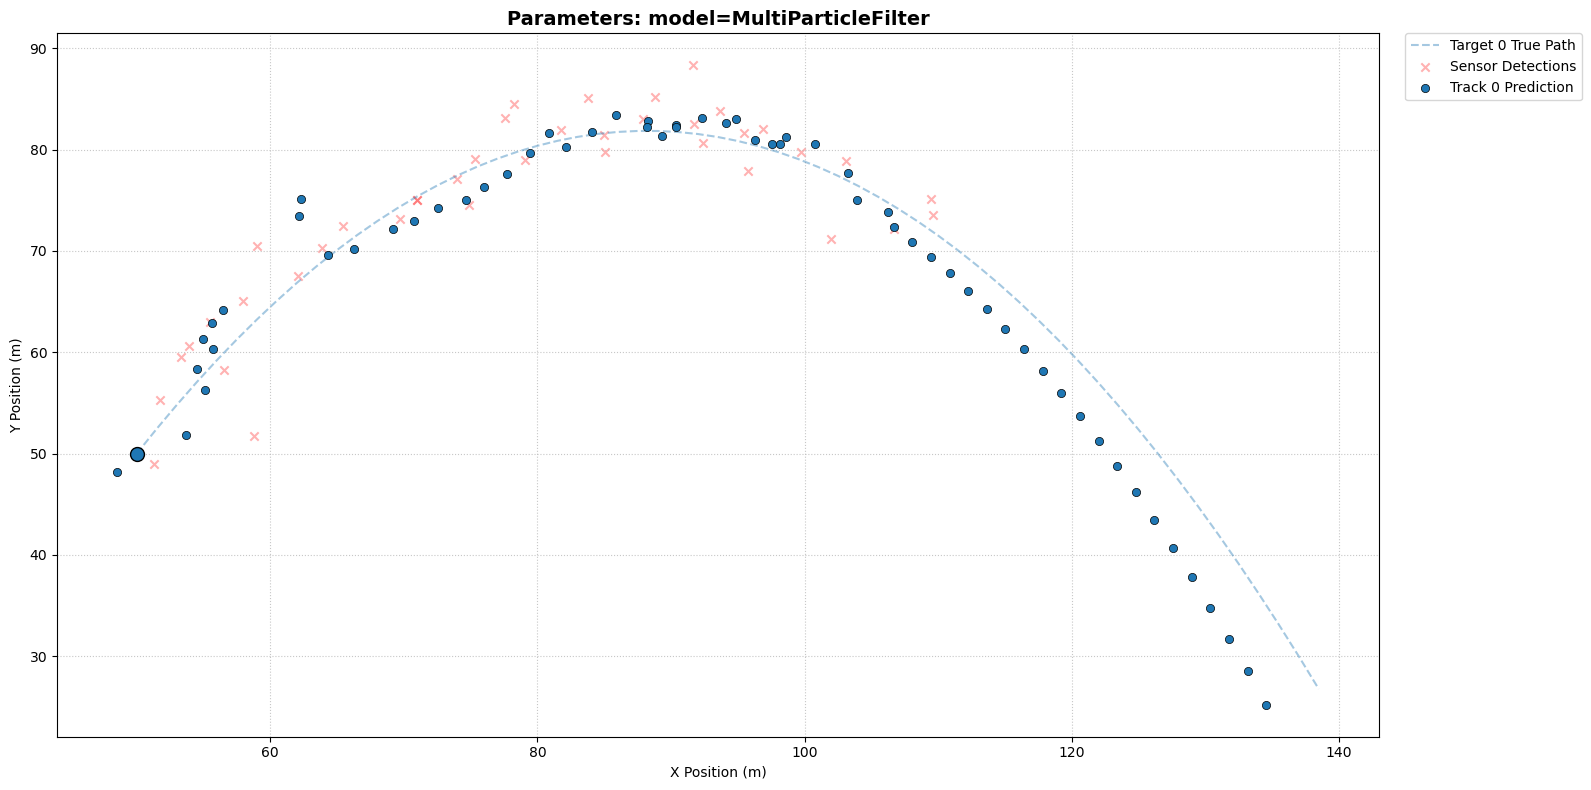

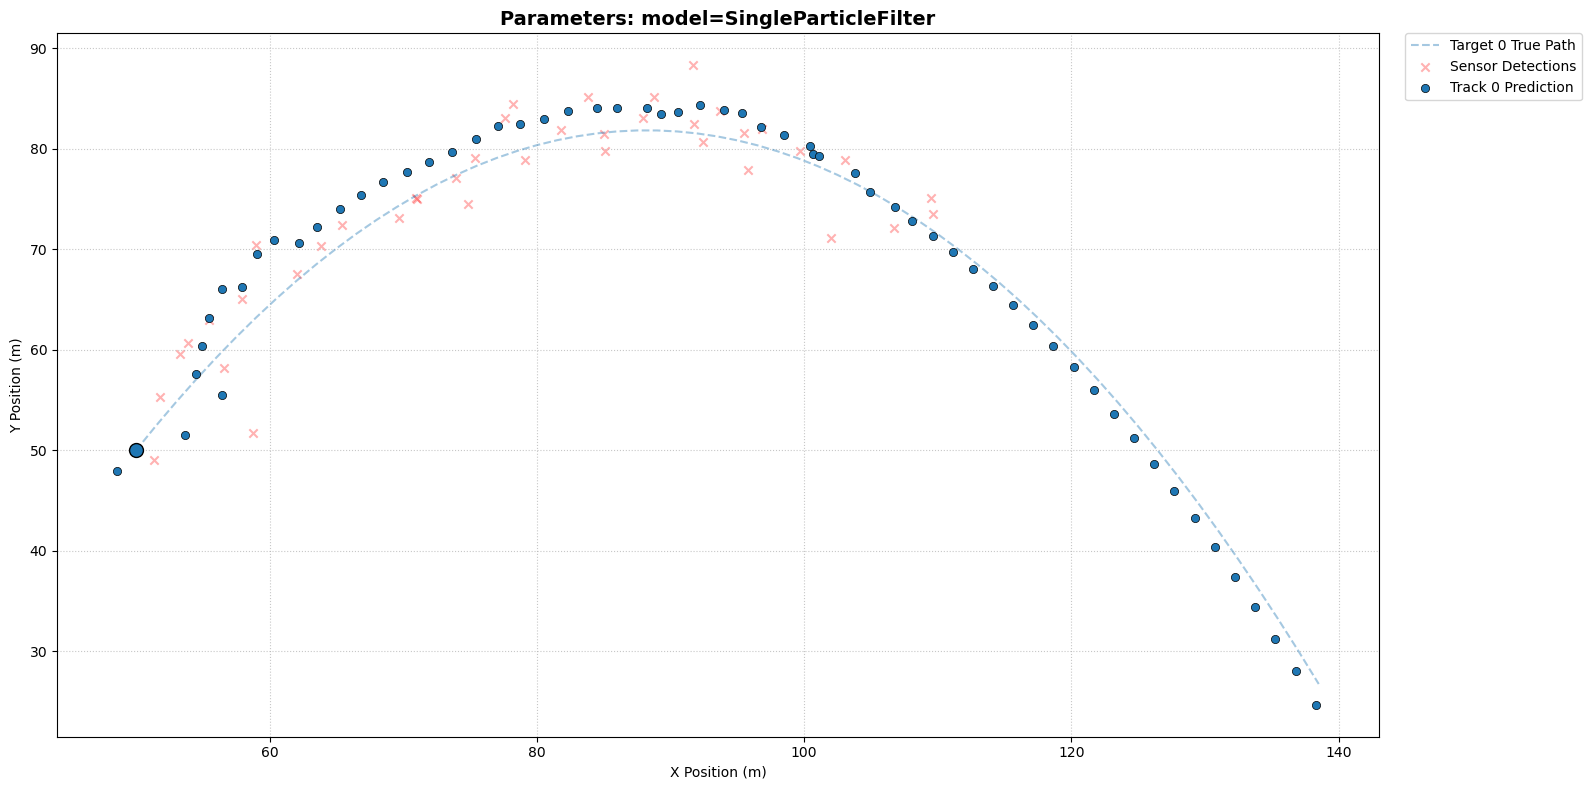

In [ ]:
true_states = np.array([[50.0, 50.0, 15.0, 25.0]], dtype=float)

tester = ParticleFilterTester(create_params(true_states, logs=[], num_particles=1024), save_dir="results")

print(true_states)
results = tester.sweep_multi({
    "model": ["MultiParticleFilter", "SingleParticleFilter"],
}, mode="grid", seed=seed)
results

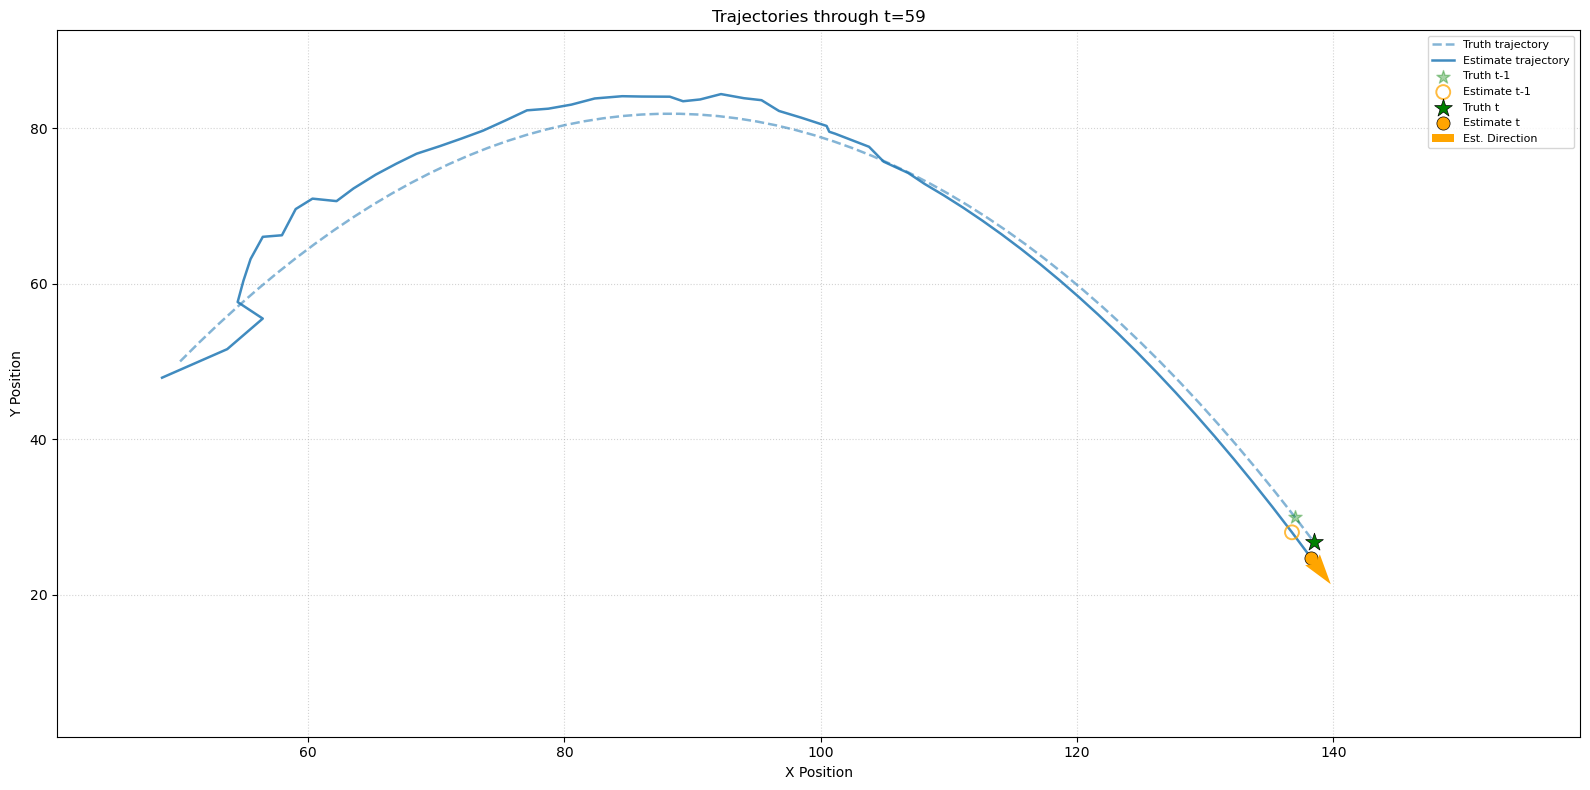

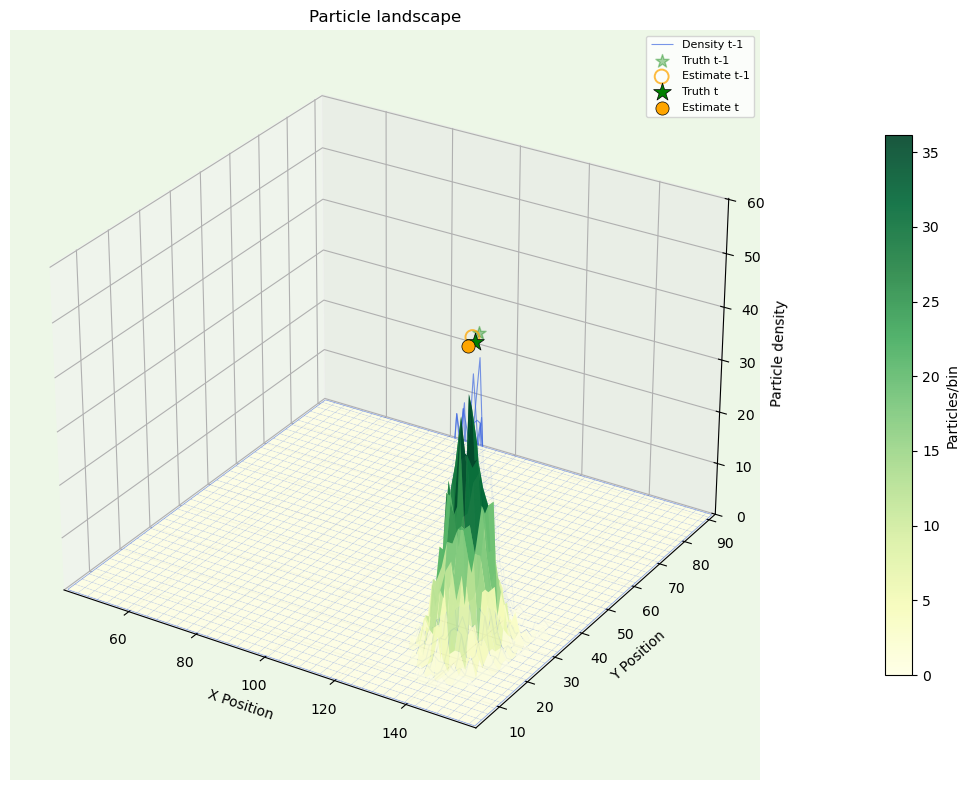

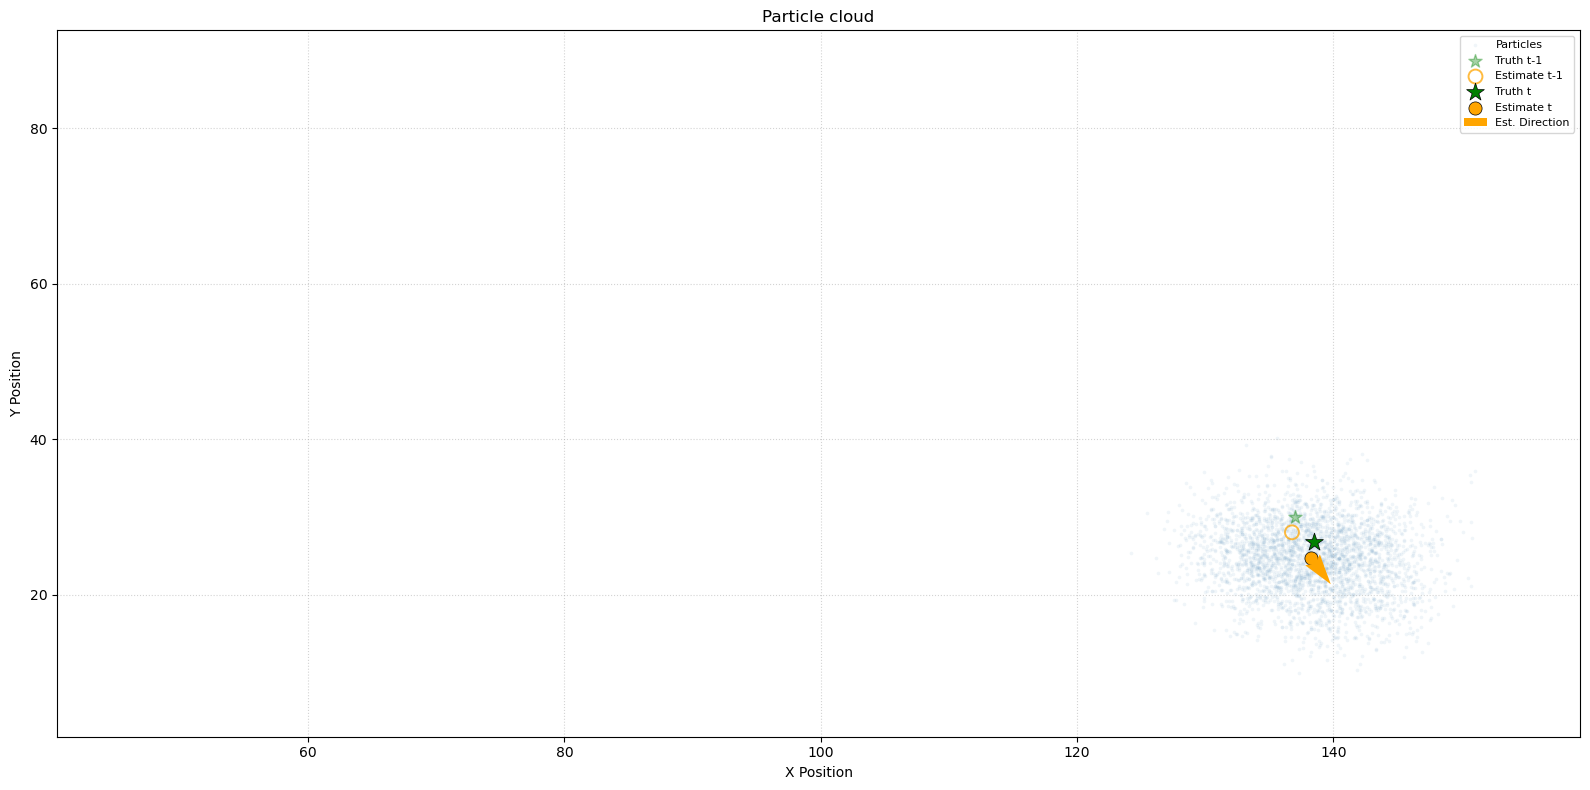

((<Figure size 1600x800 with 1 Axes>,
  <Figure size 1600x800 with 2 Axes>,
  <Figure size 1600x800 with 1 Axes>),
 (<Axes: title={'center': 'Trajectories through t=59'}, xlabel='X Position', ylabel='Y Position'>,
  <Axes3D: title={'center': 'Particle landscape'}, xlabel='X Position', ylabel='Y Position', zlabel='Particle density'>,
  <Axes: title={'center': 'Particle cloud'}, xlabel='X Position', ylabel='Y Position'>))

In [18]:
plot_particle_filter_step(time=59, **results["raw"][1])

# Exp 1: 10 Balls

[[ 30.69342017  39.22383269  -8.76402721  26.16536555]
 [ 25.50192515  15.0940603   -5.02458528   5.42325613]
 [  7.04693007  43.75590214  10.48690631  12.34254446]
 [  8.74898649  29.49364376  -9.28570568   9.70403565]
 [ 13.68163106  20.85003905  17.92435852   5.86682694]
 [ 37.15844169  29.90019209 -15.0863531   20.40061173]
 [ 15.1051873   34.46062703  -1.55839244  27.95501187]
 [ 31.41402308  10.16132122   5.05693665  18.82831824]
 [ 37.18952158  34.79575581  -0.9434084   14.79673513]
 [ 43.34529479  10.95891085 -12.51632293  14.25356271]]
Running test: model=MultiParticleFilter


/Users/Peter/MAI/Semester_1/RL/portfolios/Portfolio02_ParticleFilter/particle_filter/classes/particle_filter_multiple.py:144: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  samples = sampler.random(n=self.num_particles)


Saving plot to results/run_0.png
Running test: model=SingleParticleFilter


/Users/Peter/MAI/Semester_1/RL/portfolios/Portfolio02_ParticleFilter/particle_filter/classes/particle_filter.py:124: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  samples = sampler.random(n=self.num_particles)


Exec ParticleFilter: 30720 Particles, 10 targets. Assignment: DISTANCES
--> Cluster 3 lost. Resampling around Estimation and Observation.
--> Cluster 9 lost. Resampling around Estimation and Observation.
--> Cluster 0 lost. Resampling around Estimation and Observation.
--> Cluster 3 lost. Resampling around Estimation and Observation.
--> Cluster 7 lost. Resampling around Estimation and Observation.
--> Cluster 8 lost. Resampling around Estimation and Observation.
--> Cluster 9 lost. Resampling around Estimation and Observation.
--> Cluster 0 lost. Resampling around Estimation and Observation.
--> Cluster 2 lost. Resampling around Estimation and Observation.
--> Cluster 8 lost. Resampling around Estimation and Observation.
--> Cluster 0 lost. Resampling around Estimation and Observation.
--> Cluster 0 lost. Resampling around Estimation and Observation.
--> Cluster 5 lost. Resampling around Estimation and Observation.
--> Cluster 0 lost. Resampling around Estimation and Observation.
--> 

,label,model,obs,est,rmse_improvement,mse_improvement,mae_improvement,average_time,raw
0,model=MultiParticleFilter,MultiParticleFilter,"{'mae': 3.6340689502664714, 'mse': 16.84512191...","{'mae': 4.586620099017108, 'mse': 45.582055334...",-64.497716,-170.594986,-26.211697,2.107017,{'true_trajectory': [[[30.69342017 39.22383269...
1,model=SingleParticleFilter,SingleParticleFilter,"{'mae': 3.6340689502664714, 'mse': 16.84512191...","{'mae': 12.041916727244343, 'mse': 326.9126429...",-340.533337,-1840.696212,-231.361812,14.001821,{'true_trajectory': [[[30.69342017 39.22383269...


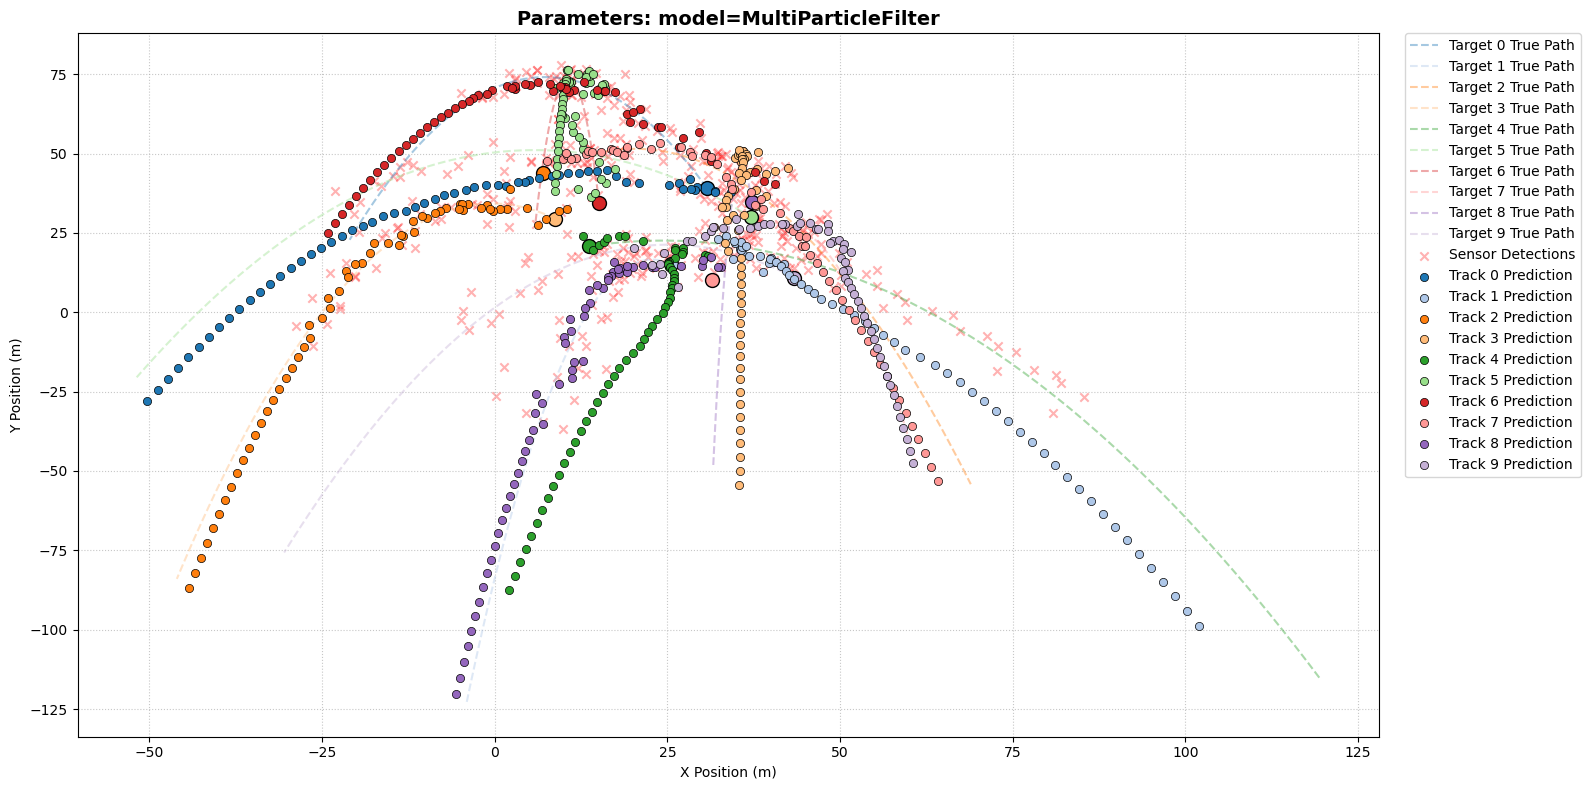

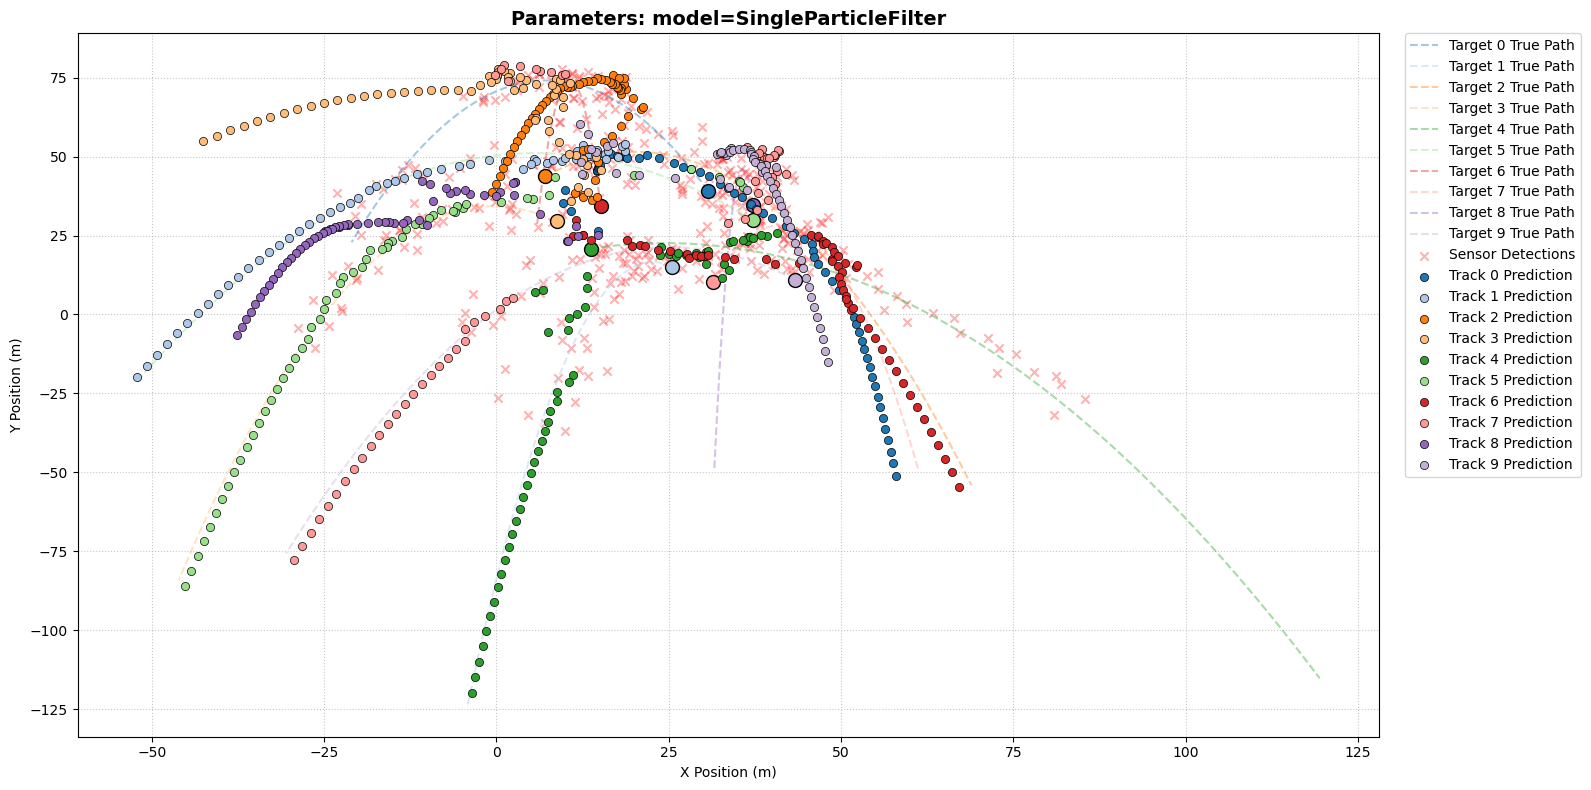

In [19]:
true_states = generate_random_balls(num_balls=10, state_bounds=STATE_BOUNDS, num_particles=1024*3)

tester = ParticleFilterTester(create_params(true_states, logs=[]), save_dir="results")

print(true_states)
results = tester.sweep_multi({
    "model": ["MultiParticleFilter", "SingleParticleFilter"],
}, mode="grid", seed=seed)
results

# Exp 2: 3 Balls - Similar init position

[[ 50.  50.  15.  25.]
 [ 50.  50. -12.  30.]
 [ 50.  50.  30.   3.]]
Running test: model=MultiParticleFilter
Saving plot to results/run_0.png
Running test: model=SingleParticleFilter
Exec ParticleFilter: 3072 Particles, 3 targets. Assignment: DISTANCES


/Users/Peter/MAI/Semester_1/RL/portfolios/Portfolio02_ParticleFilter/particle_filter/classes/particle_filter.py:124: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  samples = sampler.random(n=self.num_particles)


--> Cluster 0 lost. Resampling around Estimation and Observation.
--> Cluster 1 lost. Resampling around Estimation and Observation.
--> Cluster 1 lost. Resampling around Estimation and Observation.
--> Cluster 1 lost. Resampling around Estimation and Observation.
--> Cluster 0 lost. Resampling around Estimation and Observation.
--> Cluster 1 lost. Resampling around Estimation and Observation.
--> Cluster 0 lost. Resampling around Estimation and Observation.
--> Cluster 1 lost. Resampling around Estimation and Observation.
--> Cluster 0 lost. Resampling around Estimation and Observation.
--> Cluster 1 lost. Resampling around Estimation and Observation.
--> Cluster 1 lost. Resampling around Estimation and Observation.
--> Cluster 1 lost. Resampling around Estimation and Observation.
--> Cluster 1 lost. Resampling around Estimation and Observation.
--> Cluster 1 lost. Resampling around Estimation and Observation.
--> Cluster 1 lost. Resampling around Estimation and Observation.
--> Cluste

,label,model,obs,est,rmse_improvement,mse_improvement,mae_improvement,average_time,raw
0,model=MultiParticleFilter,MultiParticleFilter,"{'mae': 3.6537141222344665, 'mse': 17.02569808...","{'mae': 7.908173757287707, 'mse': 107.37219386...",-151.127024,-530.647820,-116.442050,0.185776,"{'true_trajectory': [[[50. 50. 15. 25.], [ 50...."
1,model=SingleParticleFilter,SingleParticleFilter,"{'mae': 3.6537141222344665, 'mse': 17.02569808...","{'mae': 24.54063108717554, 'mse': 1813.3241717...",-932.013222,-10550.512904,-571.662595,0.377831,"{'true_trajectory': [[[50. 50. 15. 25.], [ 50...."


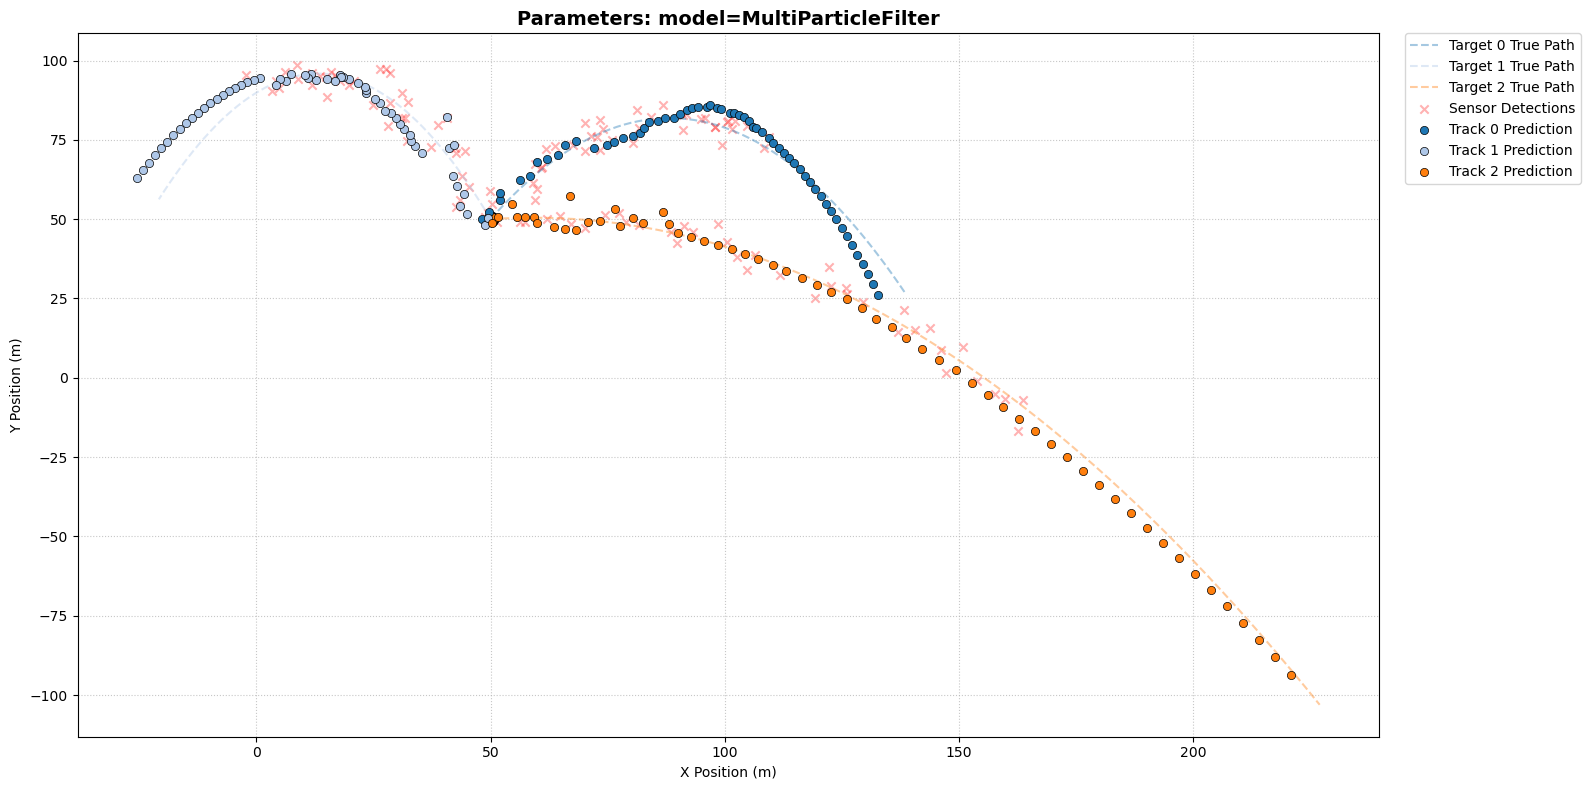

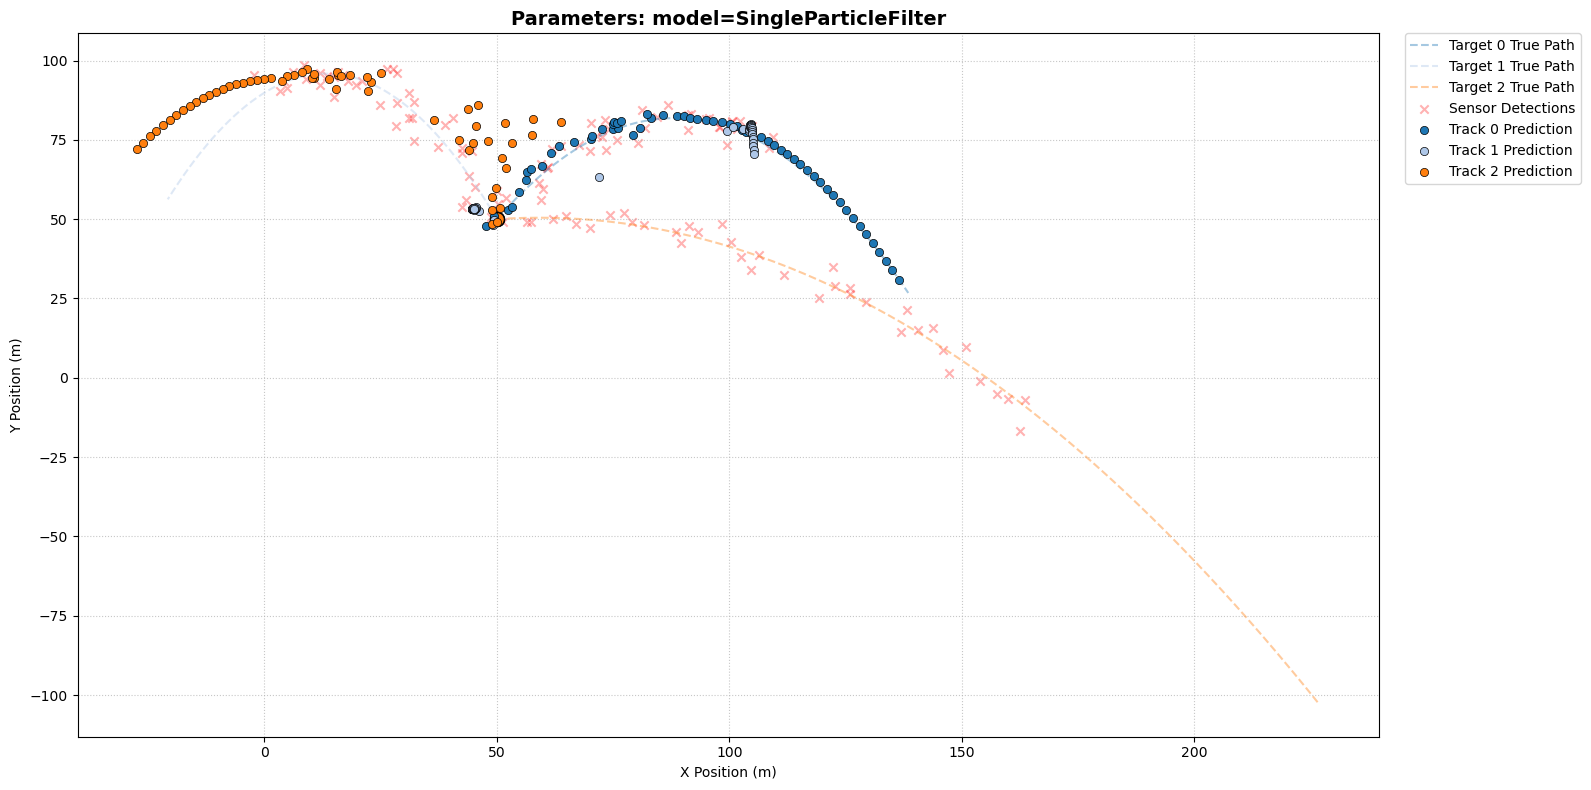

In [22]:
true_states = np.array([[50.0, 50.0, 15.0, 25.0], [50.0, 50.0, -12.0, 30.0], [50.0, 50.0, 30.0, 3.0]], dtype=float)

tester = ParticleFilterTester(create_params(true_states, logs=[], num_particles=1024), save_dir="results")

print(true_states)
results = tester.sweep_multi({
    "model": ["MultiParticleFilter", "SingleParticleFilter"],
}, mode="grid", seed=seed)
results

[[50. 50. 15. 25.]
 [10. 10. 12. 30.]
 [20. 20. 30.  3.]]
Running test: model=MultiParticleFilter
Saving plot to results/run_0.png
Running test: model=SingleParticleFilter
Exec ParticleFilter: 3072 Particles, 3 targets. Assignment: DISTANCES


/Users/Peter/MAI/Semester_1/RL/portfolios/Portfolio02_ParticleFilter/particle_filter/classes/particle_filter.py:124: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  samples = sampler.random(n=self.num_particles)


--> Cluster 2 lost. Resampling around Estimation and Observation.
--> Cluster 0 lost. Resampling around Estimation and Observation.
--> Cluster 0 lost. Resampling around Estimation and Observation.
--> Cluster 0 lost. Resampling around Estimation and Observation.
Saving plot to results/run_1.png


,label,model,obs,est,rmse_improvement,mse_improvement,mae_improvement,average_time,raw
0,model=MultiParticleFilter,MultiParticleFilter,"{'mae': 3.6537141222344665, 'mse': 17.02569808...","{'mae': 3.4765644356777377, 'mse': 14.85641986...",6.587581,12.741200,4.848482,0.171811,"{'true_trajectory': [[[50. 50. 15. 25.], [10. ..."
1,model=SingleParticleFilter,SingleParticleFilter,"{'mae': 3.6537141222344665, 'mse': 17.02569808...","{'mae': 3.6538506846448597, 'mse': 21.11005528...",-11.350513,-23.989367,-0.003738,0.354925,"{'true_trajectory': [[[50. 50. 15. 25.], [10. ..."


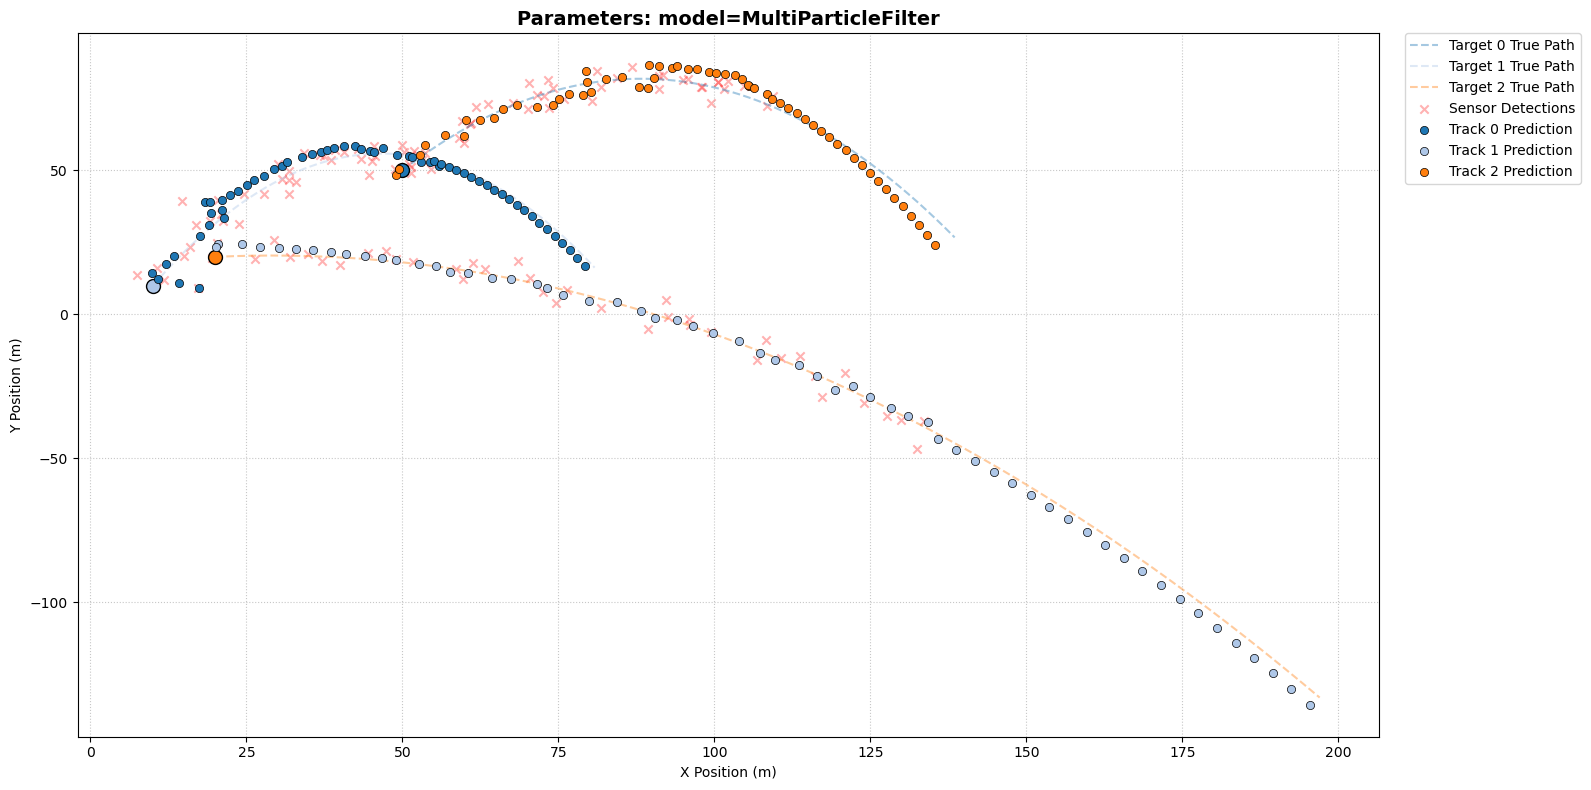

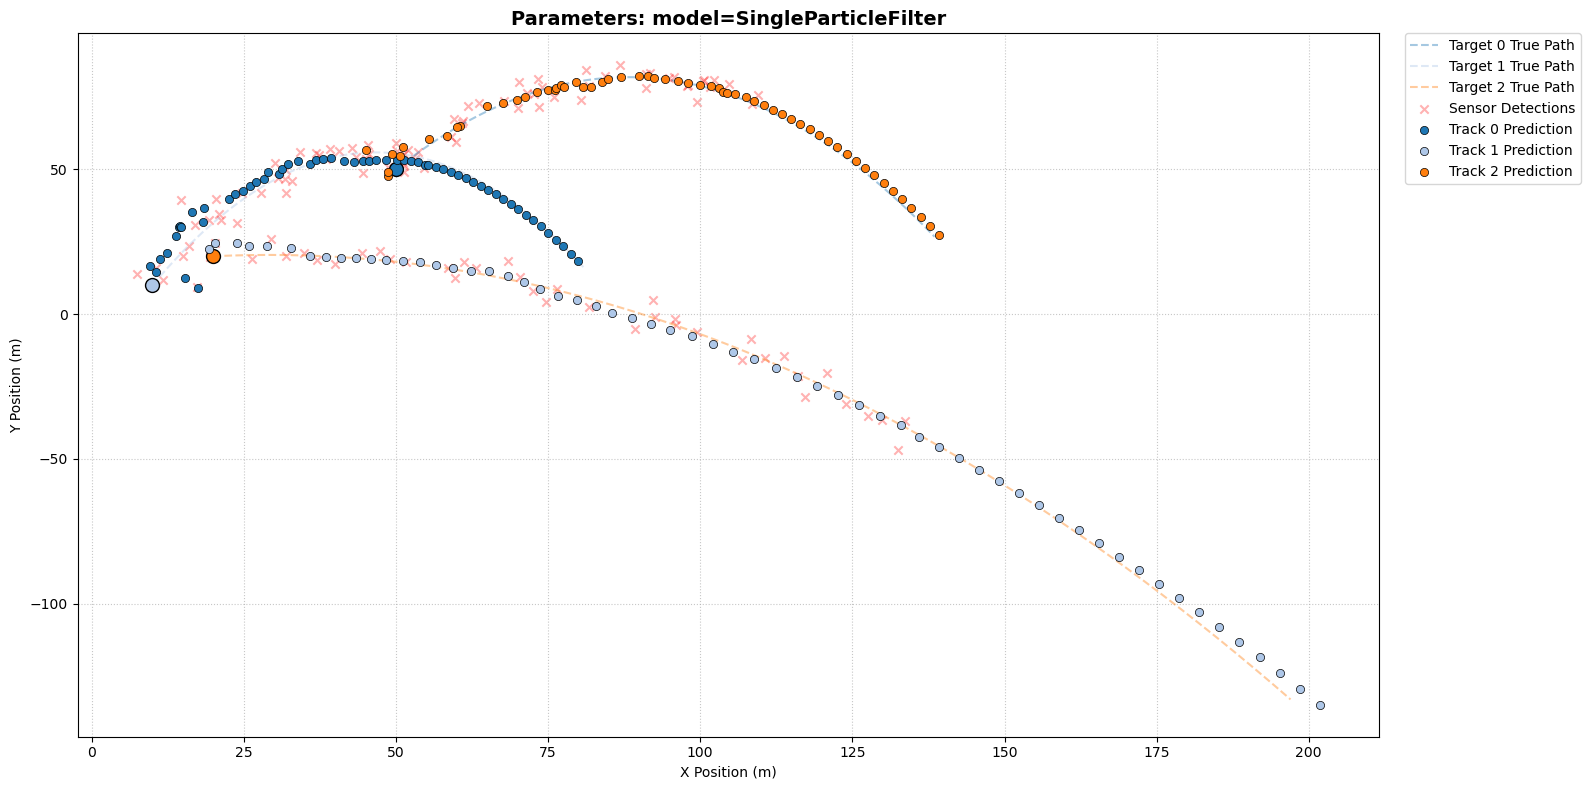

In [23]:
true_states = np.array([[50.0, 50.0, 15.0, 25.0], [10.0, 10.0, 12.0, 30.0], [20.0, 20.0, 30.0, 3.0]], dtype=float)

tester = ParticleFilterTester(create_params(true_states, logs=[], num_particles=1024), save_dir="results")

print(true_states)
results = tester.sweep_multi({
    "model": ["MultiParticleFilter", "SingleParticleFilter"],
}, mode="grid", seed=seed)
results

# Exp 3: Less particles

## 3 Balls - 50 Particles/Ball

[[ 12.55891541  15.81867805  20.09112736   4.10658494]
 [ 33.2214091   19.26075743 -22.68215602  29.90970159]
 [ 27.51716765  39.74831399 -19.90119168   4.15425648]]
Running test: model=MultiParticleFilter


/Users/Peter/MAI/Semester_1/RL/portfolios/Portfolio02_ParticleFilter/particle_filter/classes/particle_filter_multiple.py:144: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  samples = sampler.random(n=self.num_particles)


Saving plot to results/run_0.png
Running test: model=SingleParticleFilter
Exec ParticleFilter: 150 Particles, 3 targets. Assignment: DISTANCES


/Users/Peter/MAI/Semester_1/RL/portfolios/Portfolio02_ParticleFilter/particle_filter/classes/particle_filter.py:124: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  samples = sampler.random(n=self.num_particles)


--> Cluster 2 lost. Resampling around Estimation and Observation.
--> Cluster 0 lost. Resampling around Estimation and Observation.
--> Cluster 2 lost. Resampling around Estimation and Observation.
--> Cluster 2 lost. Resampling around Estimation and Observation.
--> Cluster 2 lost. Resampling around Estimation and Observation.
--> Cluster 0 lost. Resampling around Estimation and Observation.
--> Cluster 2 lost. Resampling around Estimation and Observation.
--> Cluster 0 lost. Resampling around Estimation and Observation.
--> Cluster 2 lost. Resampling around Estimation and Observation.
--> Cluster 0 lost. Resampling around Estimation and Observation.
--> Cluster 2 lost. Resampling around Estimation and Observation.
--> Cluster 0 lost. Resampling around Estimation and Observation.
--> Cluster 2 lost. Resampling around Estimation and Observation.
--> Cluster 0 lost. Resampling around Estimation and Observation.
--> Cluster 2 lost. Resampling around Estimation and Observation.
--> Cluste

,label,model,obs,est,rmse_improvement,mse_improvement,mae_improvement,average_time,raw
0,model=MultiParticleFilter,MultiParticleFilter,"{'mae': 3.6537141222344665, 'mse': 17.02569808...","{'mae': 24.01520209678468, 'mse': 1308.9001741...",-776.800520,-7587.791522,-557.281914,0.029695,{'true_trajectory': [[[12.55891541 15.81867805...
1,model=SingleParticleFilter,SingleParticleFilter,"{'mae': 3.6537141222344665, 'mse': 17.02569808...","{'mae': 31.704895996650073, 'mse': 3329.471783...",-1298.412204,-19455.566924,-767.744299,0.055717,{'true_trajectory': [[[12.55891541 15.81867805...


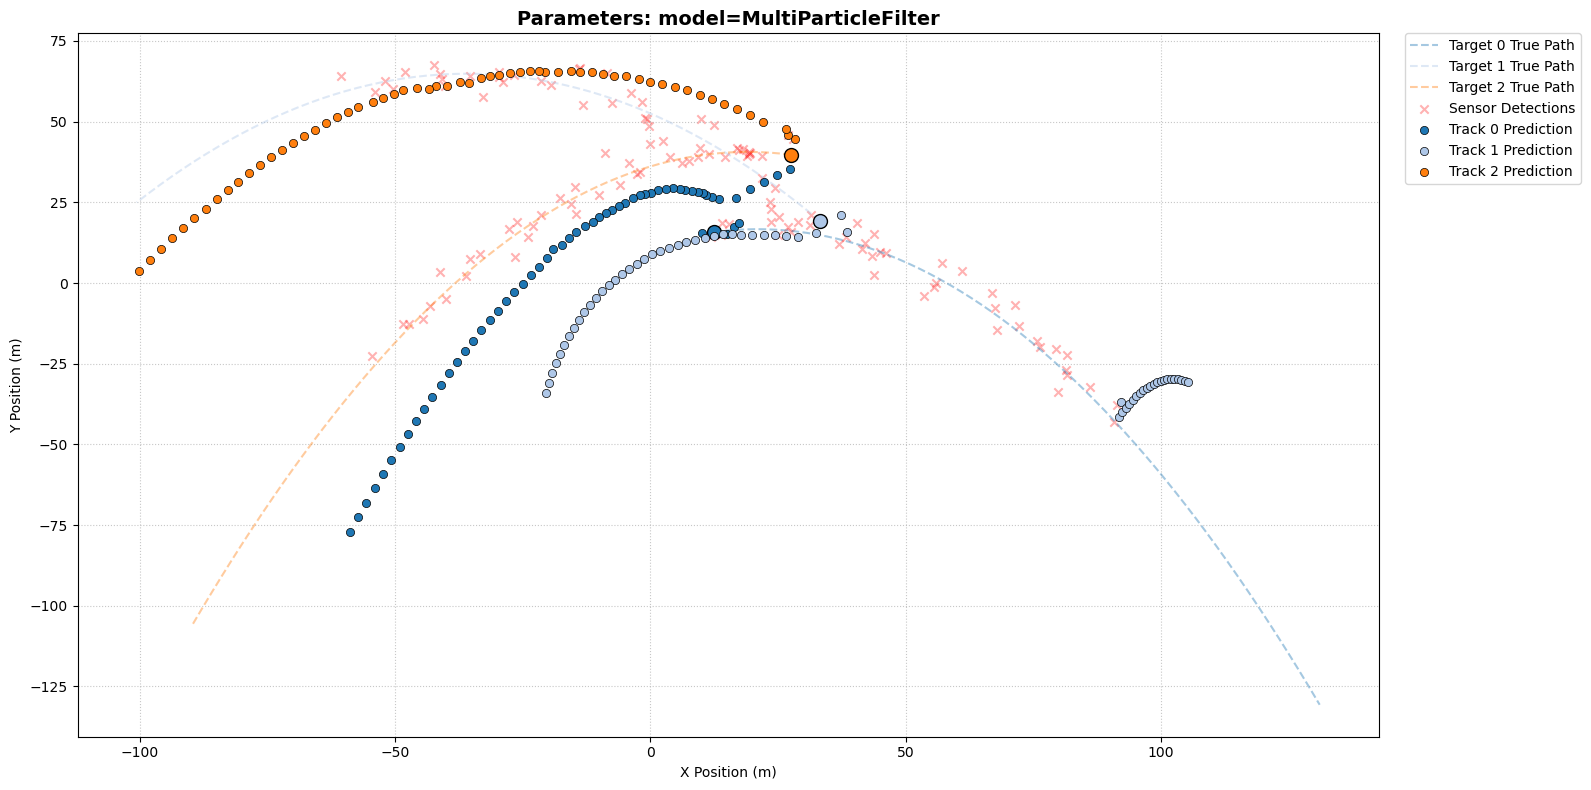

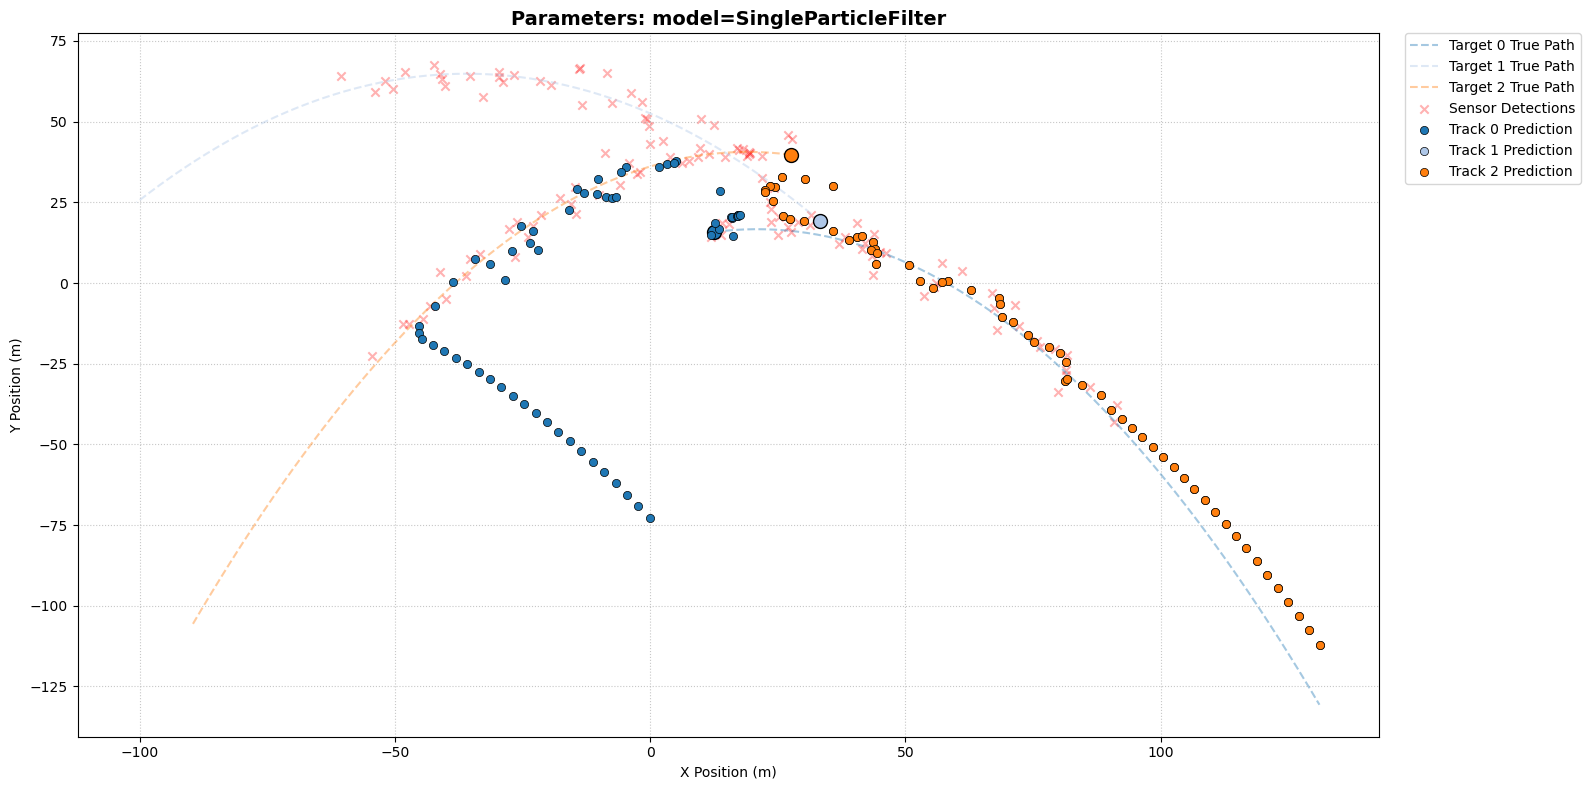

In [25]:
true_states = generate_random_balls(num_balls=3, state_bounds=STATE_BOUNDS)

tester = ParticleFilterTester(create_params(true_states, logs=[], num_particles=50), save_dir="results")

print(true_states)
results = tester.sweep_multi({
    "model": ["MultiParticleFilter", "SingleParticleFilter"],
}, mode="grid", seed=seed)
results

## 6 Balls - 50 Particles/Ball

[[ 36.48663282  27.17094316   8.5274676    5.05987816]
 [ 17.97741806   6.92034275  25.87461446  11.59810588]
 [ 28.31288922  44.79695704 -25.78904035  10.73799546]
 [ 28.66963953  15.61384081   5.0361312   11.54731536]
 [ 12.78200698  11.46072949   2.01710693  35.67490405]
 [ 31.39992876  14.13821304  23.53282784  33.08684094]]
Running test: model=MultiParticleFilter


/Users/Peter/MAI/Semester_1/RL/portfolios/Portfolio02_ParticleFilter/particle_filter/classes/particle_filter_multiple.py:144: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  samples = sampler.random(n=self.num_particles)


Saving plot to results/run_0.png
Running test: model=SingleParticleFilter
Exec ParticleFilter: 300 Particles, 6 targets. Assignment: DISTANCES


/Users/Peter/MAI/Semester_1/RL/portfolios/Portfolio02_ParticleFilter/particle_filter/classes/particle_filter.py:124: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  samples = sampler.random(n=self.num_particles)


--> Cluster 1 lost. Resampling around Estimation and Observation.
--> Cluster 1 lost. Resampling around Estimation and Observation.
--> Cluster 5 lost. Resampling around Estimation and Observation.
--> Cluster 0 lost. Resampling around Estimation and Observation.
--> Cluster 1 lost. Resampling around Estimation and Observation.
--> Cluster 2 lost. Resampling around Estimation and Observation.
--> Cluster 4 lost. Resampling around Estimation and Observation.
--> Cluster 2 lost. Resampling around Estimation and Observation.
--> Cluster 4 lost. Resampling around Estimation and Observation.
--> Cluster 1 lost. Resampling around Estimation and Observation.
--> Cluster 4 lost. Resampling around Estimation and Observation.
--> Cluster 1 lost. Resampling around Estimation and Observation.
--> Cluster 4 lost. Resampling around Estimation and Observation.
--> Cluster 1 lost. Resampling around Estimation and Observation.
--> Cluster 4 lost. Resampling around Estimation and Observation.
--> Cluste

,label,model,obs,est,rmse_improvement,mse_improvement,mae_improvement,average_time,raw
0,model=MultiParticleFilter,MultiParticleFilter,"{'mae': 3.7128253279349406, 'mse': 17.34131460...","{'mae': 16.32941844412589, 'mse': 361.21314554...",-356.394881,-1982.962877,-339.811114,0.025967,{'true_trajectory': [[[36.48663282 27.17094316...
1,model=SingleParticleFilter,SingleParticleFilter,"{'mae': 3.7128253279349406, 'mse': 17.34131460...","{'mae': 21.718478807435318, 'mse': 1926.477848...",-954.000947,-11009.179972,-484.958270,0.125769,{'true_trajectory': [[[36.48663282 27.17094316...


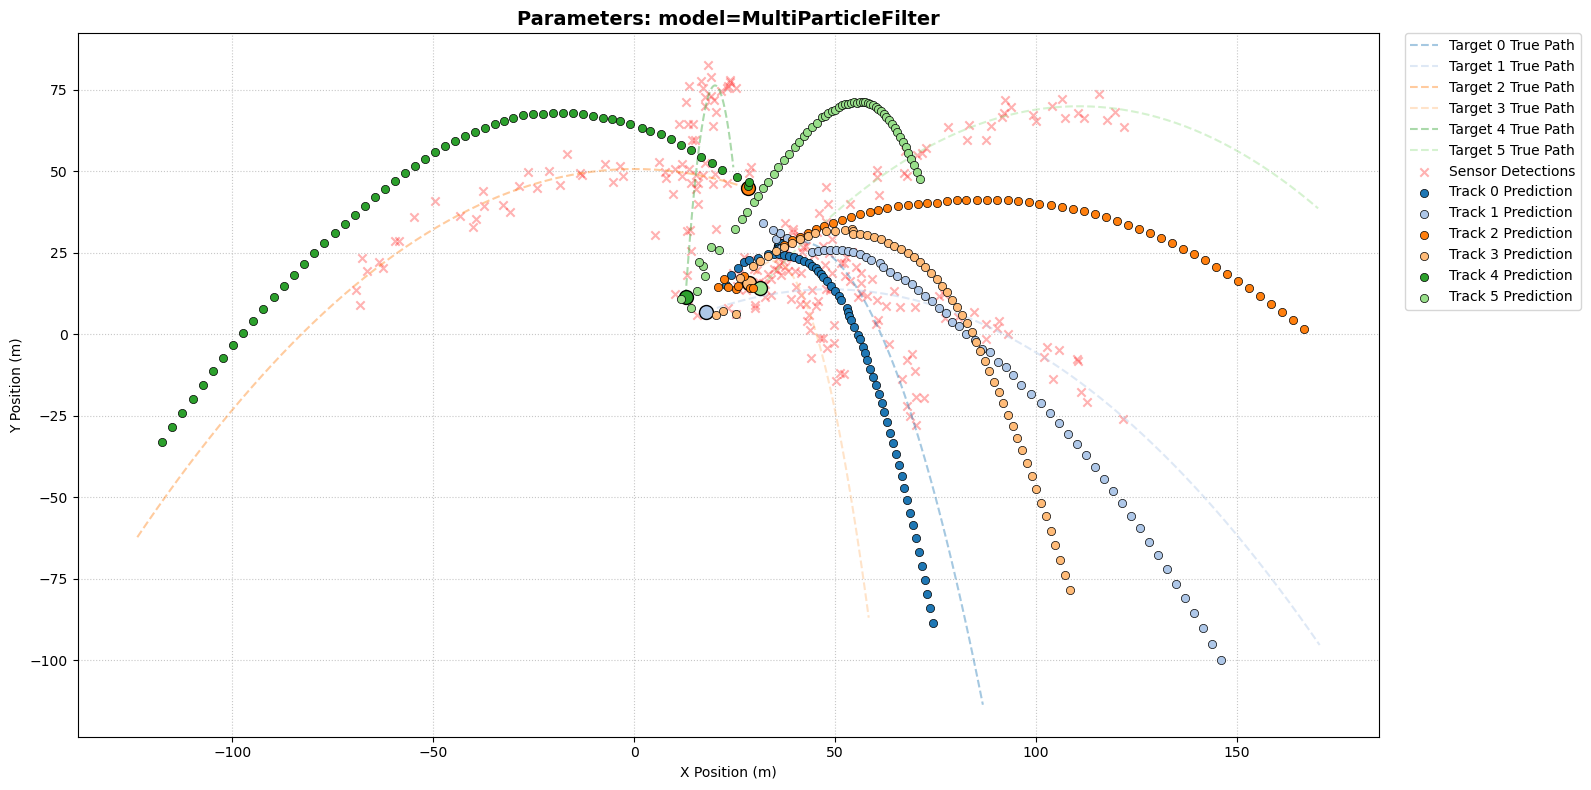

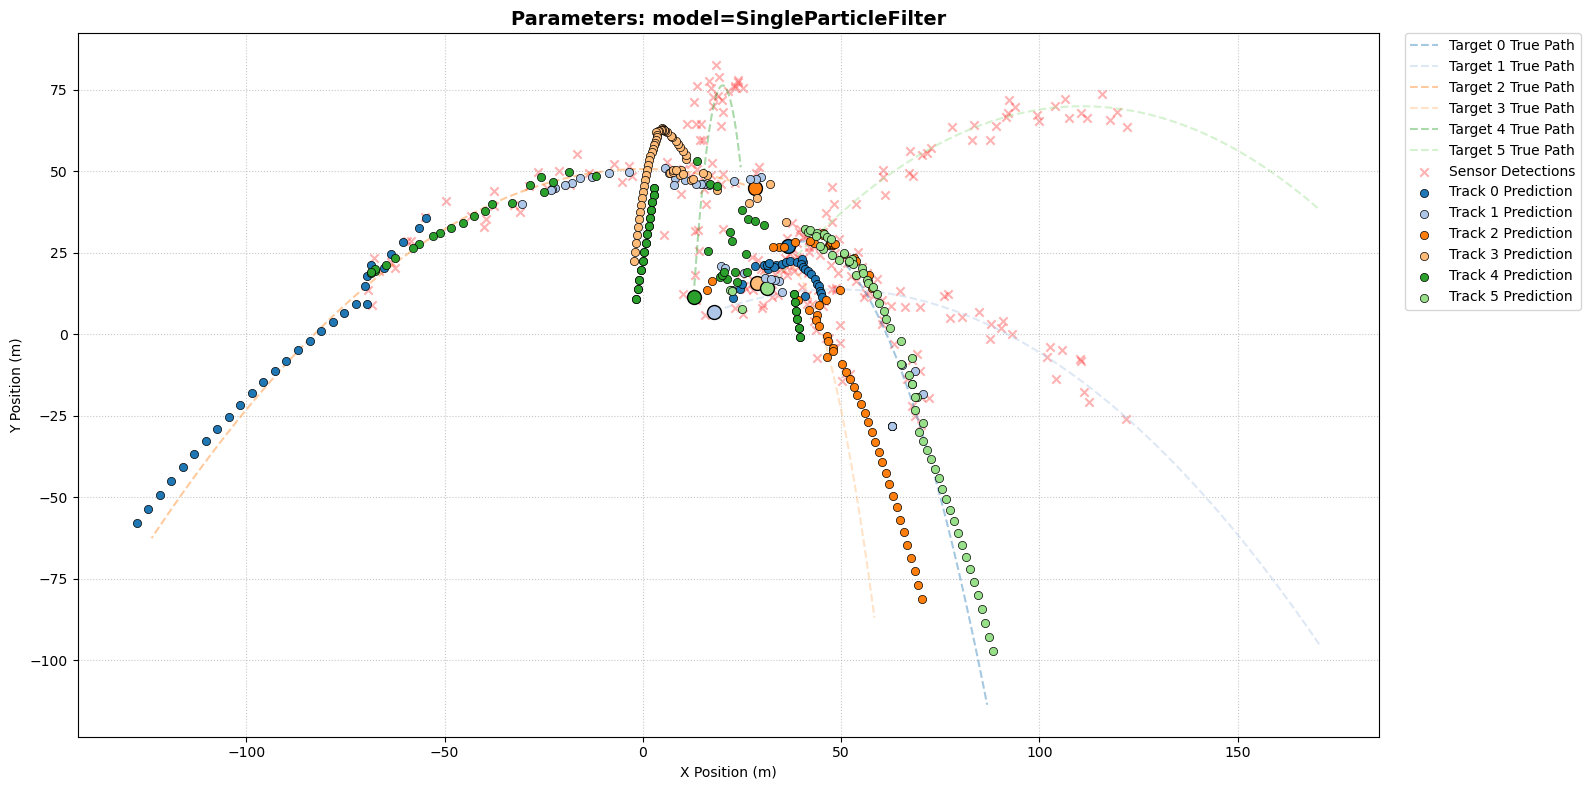

In [26]:
true_states = generate_random_balls(num_balls=6, state_bounds=STATE_BOUNDS)

tester = ParticleFilterTester(create_params(true_states, logs=[], num_particles=50), save_dir="results")

print(true_states)
results = tester.sweep_multi({
    "model": ["MultiParticleFilter", "SingleParticleFilter"],
}, mode="grid", seed=seed)
results

# Exp 4: High noise

## High process_noise

[[ 16.39042526   8.54250795 -17.17364606  29.81943605]
 [ 44.46964285  12.98679434 -21.12633054  33.26255906]
 [ 25.49205563  43.75410504 -26.37285621  35.09509565]]
Running test: model=MultiParticleFilter
Saving plot to results/run_0.png
Running test: model=SingleParticleFilter
Exec ParticleFilter: 3072 Particles, 3 targets. Assignment: DISTANCES


/Users/Peter/MAI/Semester_1/RL/portfolios/Portfolio02_ParticleFilter/particle_filter/classes/particle_filter.py:124: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  samples = sampler.random(n=self.num_particles)


--> Cluster 1 lost. Resampling around Estimation and Observation.
Saving plot to results/run_1.png


,label,model,obs,est,rmse_improvement,mse_improvement,mae_improvement,average_time,raw
0,model=MultiParticleFilter,MultiParticleFilter,"{'mae': 1.217904707411489, 'mse': 1.8917442318...","{'mae': 0.9432047335441166, 'mse': 1.186340707...",20.809423,37.288525,22.555129,0.248465,{'true_trajectory': [[[ 16.39042526 8.542507...
1,model=SingleParticleFilter,SingleParticleFilter,"{'mae': 1.217904707411489, 'mse': 1.8917442318...","{'mae': 1.0102565875006535, 'mse': 2.873635534...",-23.249349,-51.904020,17.049620,0.495425,{'true_trajectory': [[[ 16.39042526 8.542507...


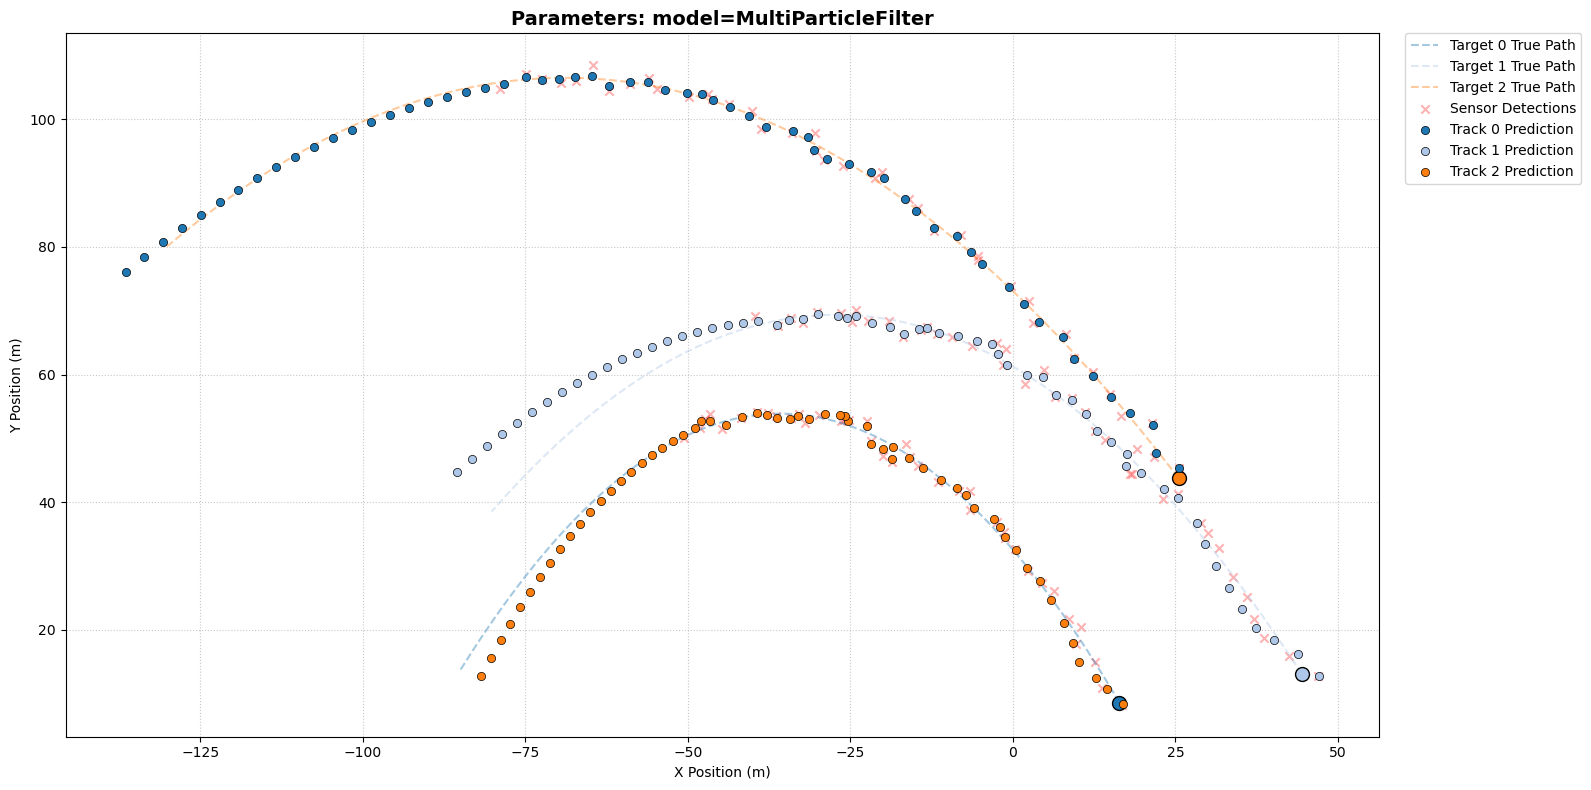

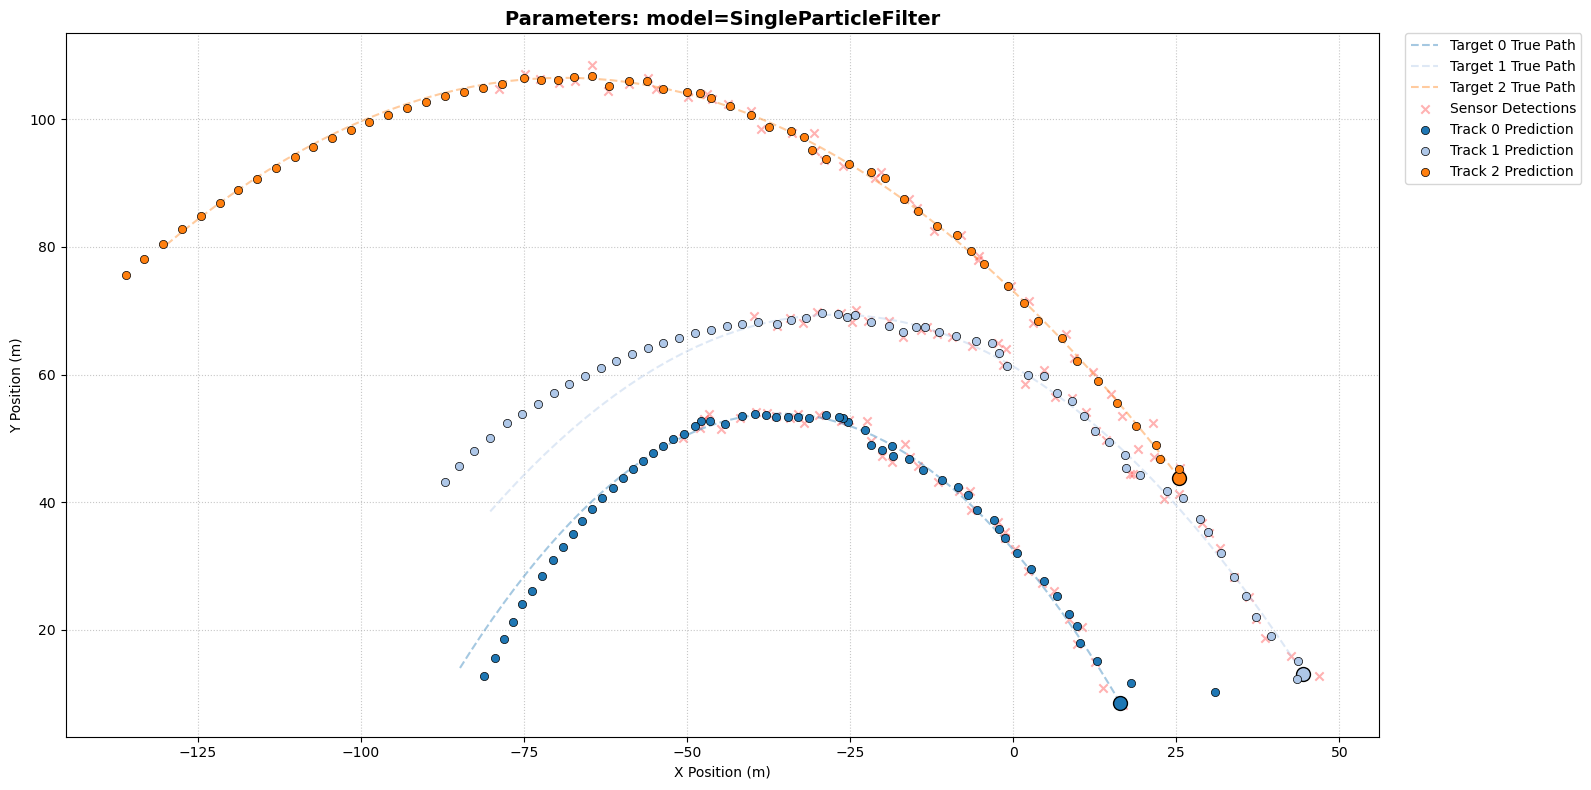

In [28]:
true_states = generate_random_balls(num_balls=3, state_bounds=STATE_BOUNDS)

tester = ParticleFilterTester(create_params(true_states, logs=[], num_particles=1024, process_noise=100.0, measuremnt_noise=1.0), save_dir="results")

print(true_states)
results = tester.sweep_multi({
    "model": ["MultiParticleFilter", "SingleParticleFilter"],
}, mode="grid", seed=seed)
results

## High measurement_noise

[[ 16.95038745  42.3706302   -4.62979521   5.46842912]
 [ 27.47682014  14.8588175  -23.87940566  26.5505017 ]
 [ 18.93966782  15.34428299 -10.51128619  13.9488249 ]]
Running test: model=MultiParticleFilter
Saving plot to results/run_0.png
Running test: model=SingleParticleFilter
Exec ParticleFilter: 3072 Particles, 3 targets. Assignment: DISTANCES


/Users/Peter/MAI/Semester_1/RL/portfolios/Portfolio02_ParticleFilter/particle_filter/classes/particle_filter.py:124: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  samples = sampler.random(n=self.num_particles)


--> Cluster 2 lost. Resampling around Estimation and Observation.
--> Cluster 2 lost. Resampling around Estimation and Observation.
--> Cluster 2 lost. Resampling around Estimation and Observation.
--> Cluster 2 lost. Resampling around Estimation and Observation.
--> Cluster 2 lost. Resampling around Estimation and Observation.
--> Cluster 2 lost. Resampling around Estimation and Observation.
--> Cluster 2 lost. Resampling around Estimation and Observation.
--> Cluster 1 lost. Resampling around Estimation and Observation.
--> Cluster 2 lost. Resampling around Estimation and Observation.
--> Cluster 2 lost. Resampling around Estimation and Observation.
--> Cluster 1 lost. Resampling around Estimation and Observation.
--> Cluster 2 lost. Resampling around Estimation and Observation.
--> Cluster 2 lost. Resampling around Estimation and Observation.
--> Cluster 0 lost. Resampling around Estimation and Observation.
--> Cluster 2 lost. Resampling around Estimation and Observation.
--> Cluste

,label,model,obs,est,rmse_improvement,mse_improvement,mae_improvement,average_time,raw
0,model=MultiParticleFilter,MultiParticleFilter,"{'mae': 11.74518966615371, 'mse': 180.00339202...","{'mae': 9.357375876343497, 'mse': 111.54033494...",21.281714,38.034315,20.330142,0.234779,{'true_trajectory': [[[16.95038745 42.3706302 ...
1,model=SingleParticleFilter,SingleParticleFilter,"{'mae': 11.74518966615371, 'mse': 180.00339202...","{'mae': 10.740057786729611, 'mse': 140.0500638...",11.793354,22.195875,8.557817,0.575174,{'true_trajectory': [[[16.95038745 42.3706302 ...


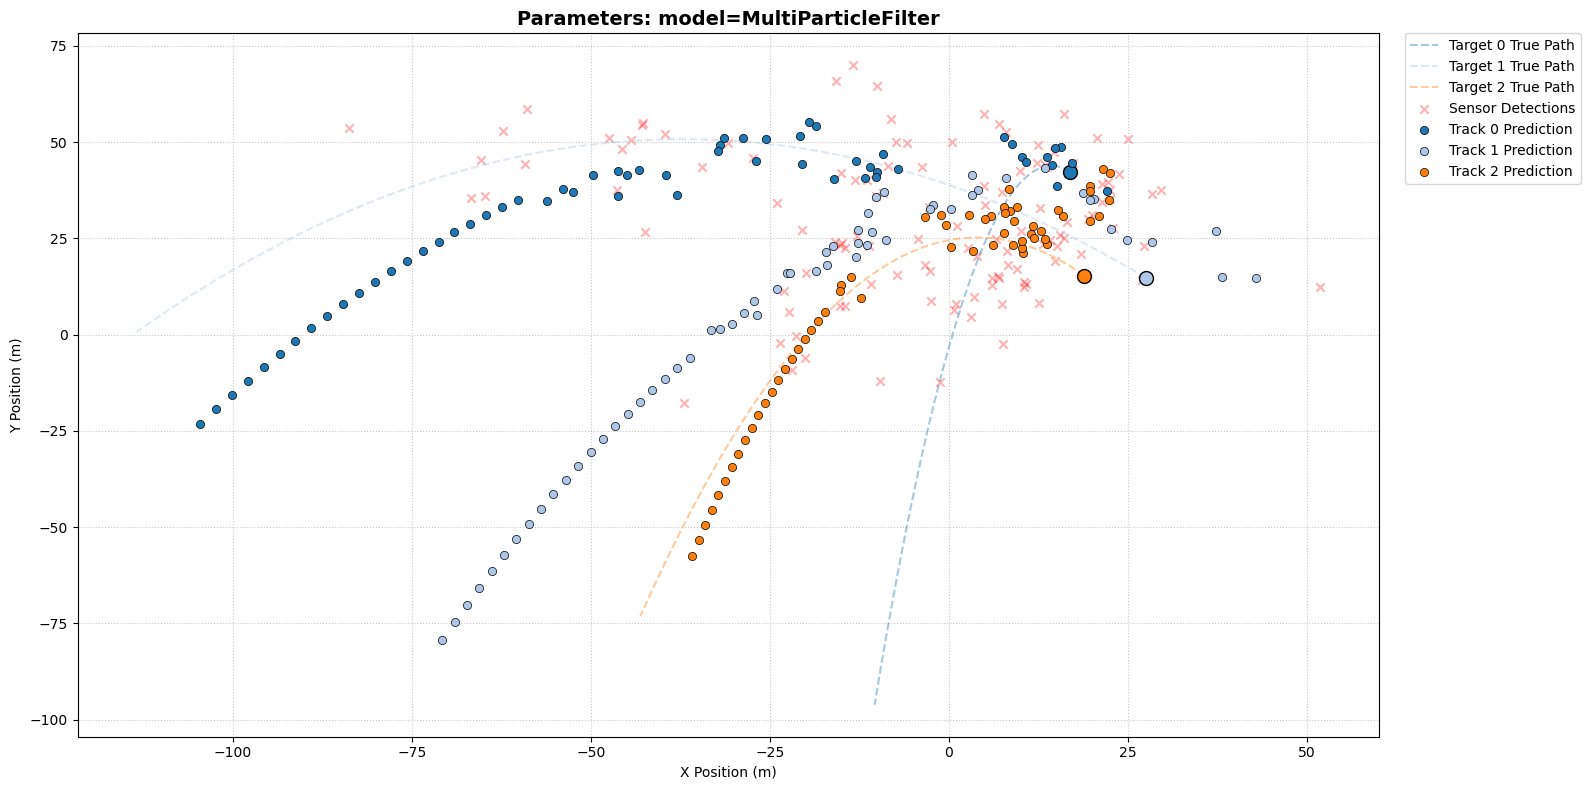

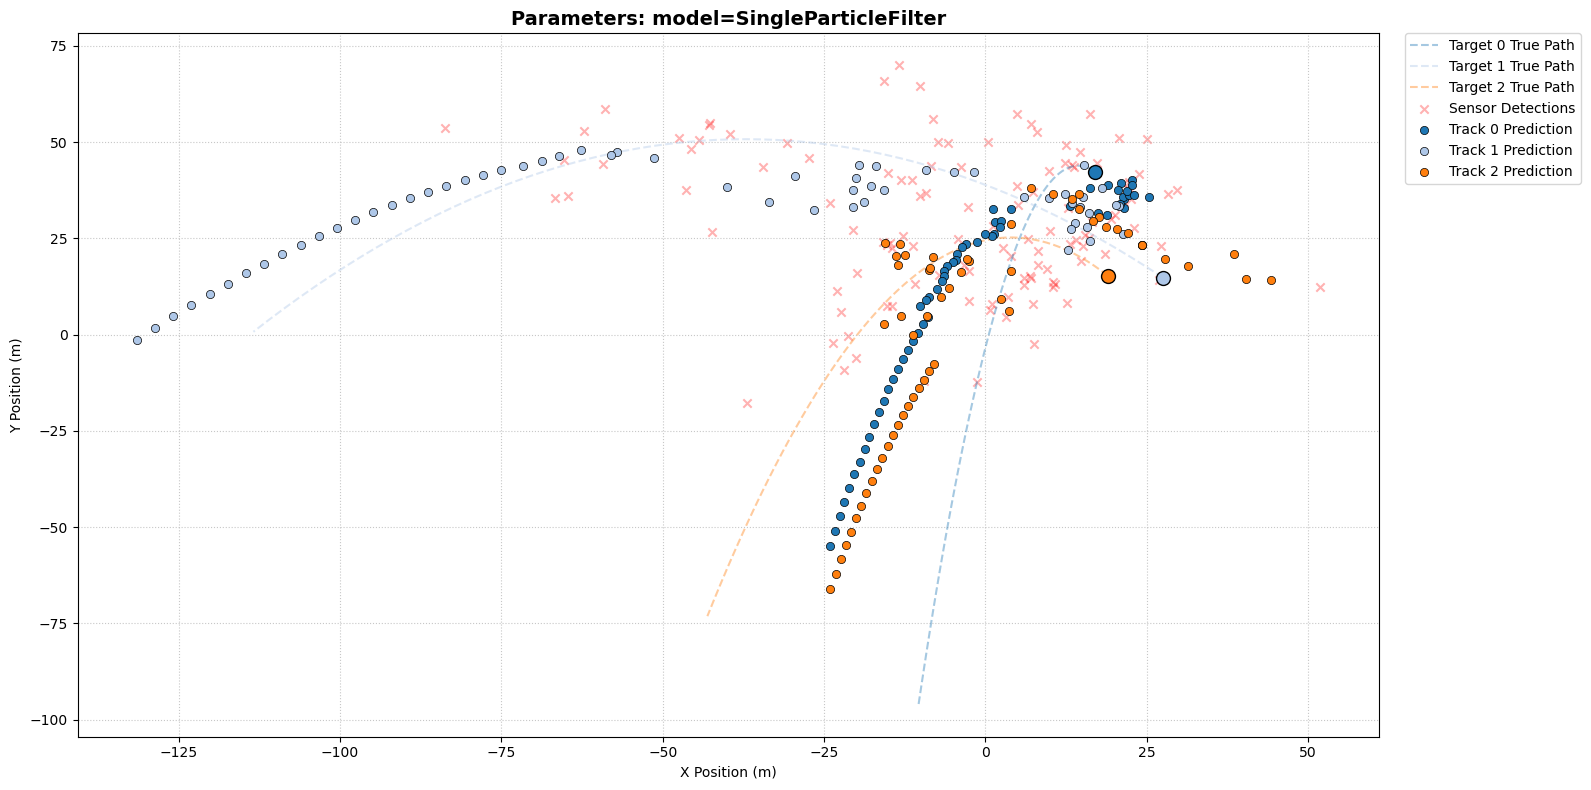

In [29]:
true_states = generate_random_balls(num_balls=3, state_bounds=STATE_BOUNDS)

tester = ParticleFilterTester(create_params(true_states, logs=[], num_particles=1024, process_noise=1.0, measuremnt_noise=100.0), save_dir="results")

print(true_states)
results = tester.sweep_multi({
    "model": ["MultiParticleFilter", "SingleParticleFilter"],
}, mode="grid", seed=seed)
results

## Both high

[[ 15.51419999  25.71786626 -24.3653779   23.33576016]
 [ 28.76118407  13.52049455  14.50582185  30.11881818]
 [ 23.42853633  10.65282911  -3.05129166  31.63988622]]
Running test: model=MultiParticleFilter
Saving plot to results/run_0.png
Running test: model=SingleParticleFilter
Exec ParticleFilter: 3072 Particles, 3 targets. Assignment: DISTANCES


/Users/Peter/MAI/Semester_1/RL/portfolios/Portfolio02_ParticleFilter/particle_filter/classes/particle_filter.py:124: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  samples = sampler.random(n=self.num_particles)


--> Cluster 1 lost. Resampling around Estimation and Observation.
--> Cluster 2 lost. Resampling around Estimation and Observation.
--> Cluster 1 lost. Resampling around Estimation and Observation.
--> Cluster 1 lost. Resampling around Estimation and Observation.
--> Cluster 1 lost. Resampling around Estimation and Observation.
--> Cluster 1 lost. Resampling around Estimation and Observation.
--> Cluster 1 lost. Resampling around Estimation and Observation.
--> Cluster 1 lost. Resampling around Estimation and Observation.
--> Cluster 0 lost. Resampling around Estimation and Observation.
--> Cluster 0 lost. Resampling around Estimation and Observation.
--> Cluster 0 lost. Resampling around Estimation and Observation.
Saving plot to results/run_1.png


,label,model,obs,est,rmse_improvement,mse_improvement,mae_improvement,average_time,raw
0,model=MultiParticleFilter,MultiParticleFilter,"{'mae': 12.053441252233371, 'mse': 184.2829020...","{'mae': 6.380763999553991, 'mse': 54.233803695...",45.750903,70.570355,47.062720,0.229302,{'true_trajectory': [[[ 15.51419999 25.717866...
1,model=SingleParticleFilter,SingleParticleFilter,"{'mae': 12.053441252233371, 'mse': 184.2829020...","{'mae': 9.902282335770545, 'mse': 217.23065615...",-8.572049,-17.878899,17.846844,0.547446,{'true_trajectory': [[[ 15.51419999 25.717866...


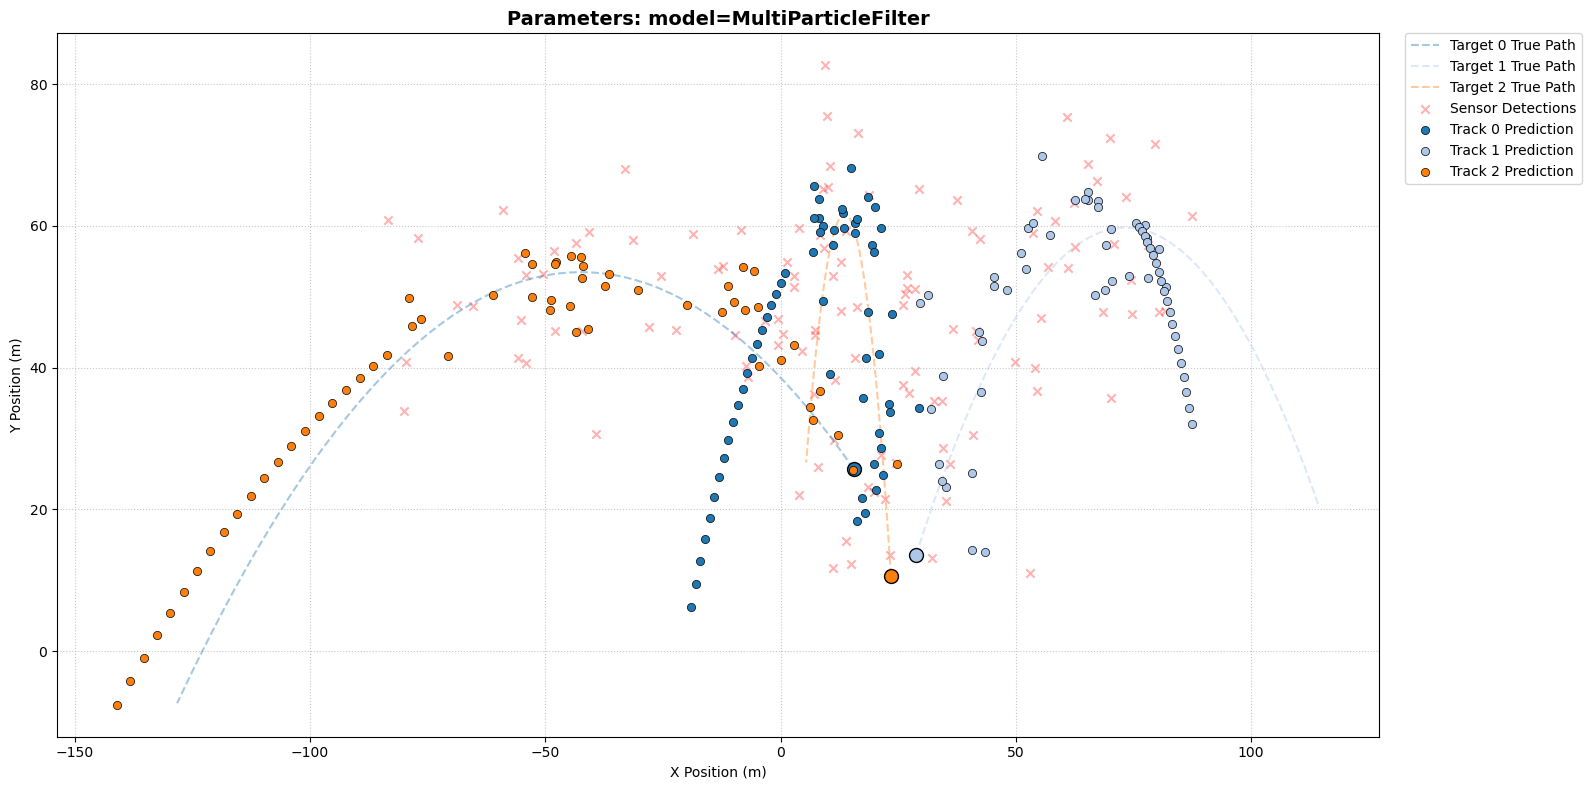

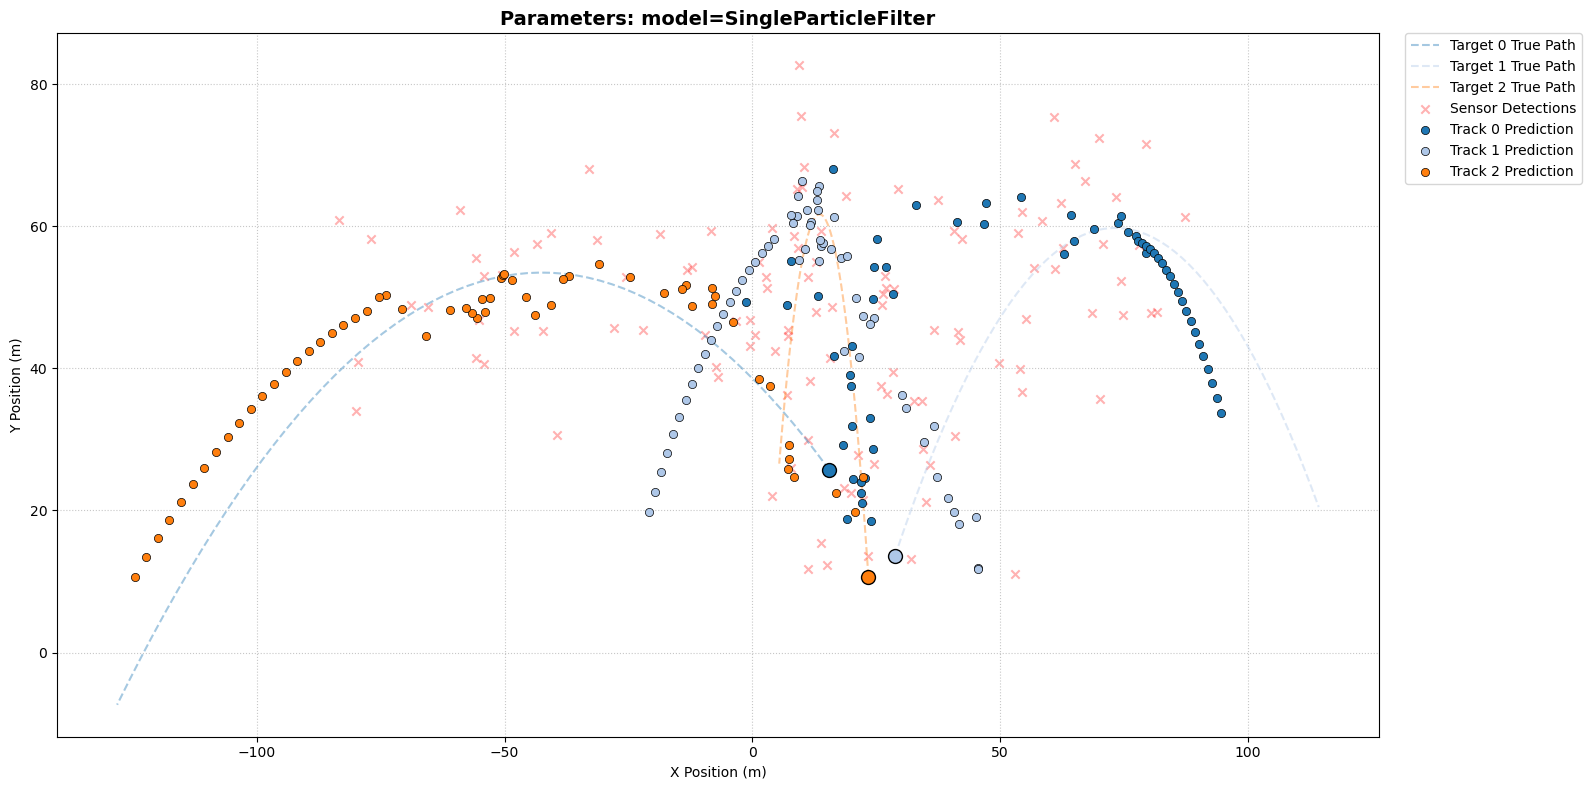

In [30]:
true_states = generate_random_balls(num_balls=3, state_bounds=STATE_BOUNDS)

tester = ParticleFilterTester(create_params(true_states, logs=[], num_particles=1024, process_noise=100.0, measuremnt_noise=100.0), save_dir="results")

print(true_states)
results = tester.sweep_multi({
    "model": ["MultiParticleFilter", "SingleParticleFilter"],
}, mode="grid", seed=seed)
results

# Exp 5: High Step_size

[[27.12879955 36.53435337 15.13050266  6.46272169]
 [31.33976521  8.57493891 21.41416132  8.01902453]
 [27.17869497 14.3985042  -2.41336706  7.85927428]]
Running test: model=MultiParticleFilter
Saving plot to results/run_0.png


,label,model,obs,est,rmse_improvement,mse_improvement,mae_improvement,average_time,raw
0,model=MultiParticleFilter,MultiParticleFilter,"{'mae': 1.2179047073988756, 'mse': 1.891744231...","{'mae': 1.696787823039812, 'mse': 17.404367053...",-203.317807,-820.016922,-39.320245,0.430948,{'true_trajectory': [[[27.12879955 36.53435337...


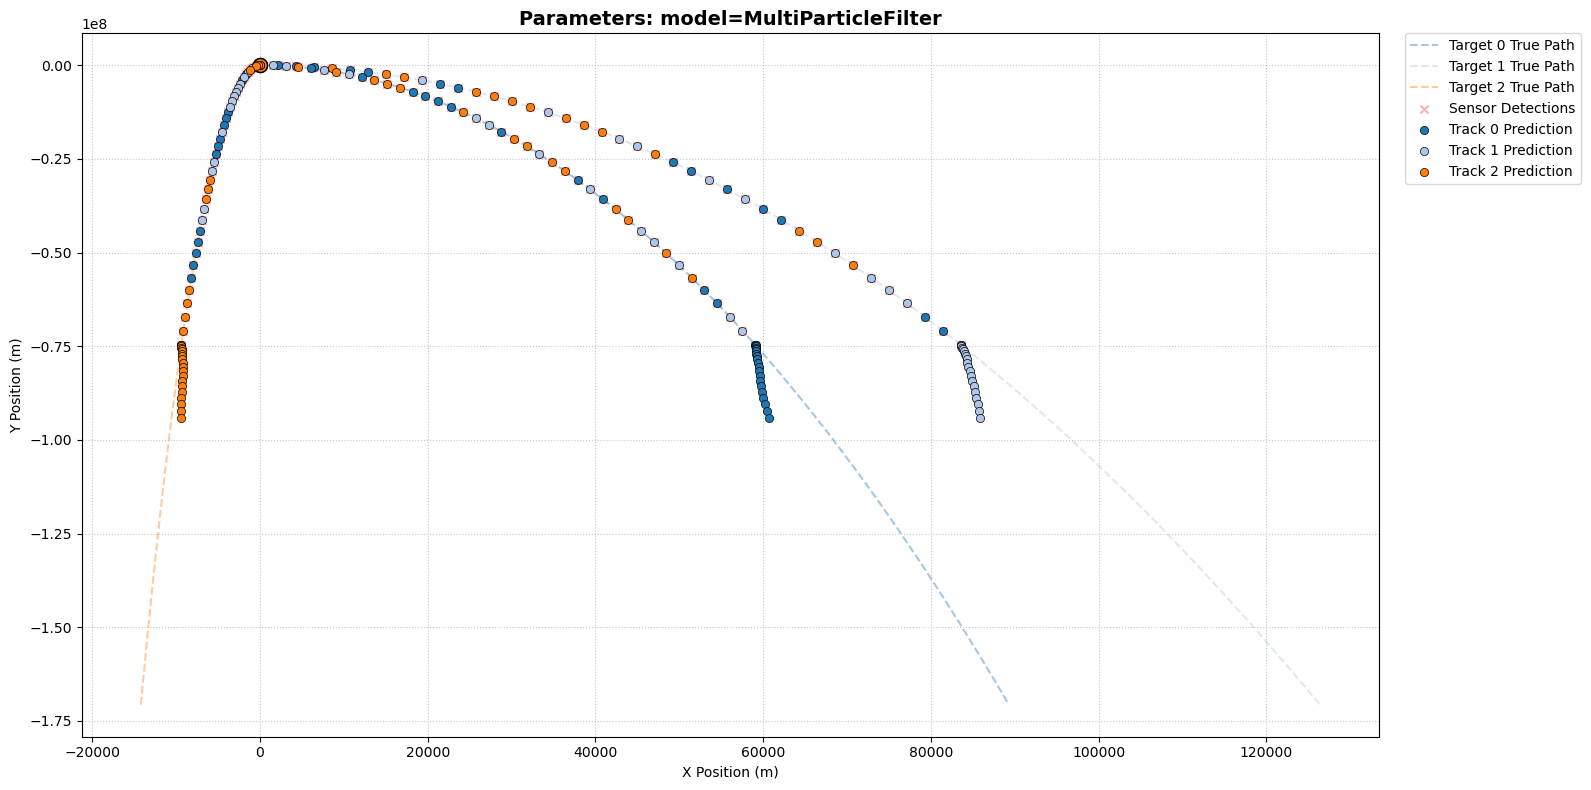

In [38]:
true_states = generate_random_balls(num_balls=3, state_bounds=STATE_BOUNDS)

tester = ParticleFilterTester(create_params(true_states, logs=[], num_particles=1024, process_noise=1.0, measuremnt_noise=1.0, step_size=100.0), save_dir="results")

print(true_states)
results = tester.sweep_multi({
    "model": ["MultiParticleFilter"],
}, mode="grid", seed=seed)
results

<img src="img/TransitionModel_1Noise_vs_100Noise.png">